In [1]:
import warnings
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, fetch_openml,load_iris,fetch_california_housing
from sklearn.feature_selection import mutual_info_regression, f_regression, RFE, SelectFromModel, SelectKBest, f_classif
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import (
RepeatedStratifiedKFold, 
cross_val_score, 
train_test_split, 
GridSearchCV,
cross_val_predict, 
learning_curve, 
validation_curve)
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error,zero_one_loss, roc_auc_score,root_mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from os.path import join as pjoin
from sklearn.feature_extraction.text import TfidfVectorizer
#sharper plots
%config InlineBackend.figure_format = 'retina'
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV,
                                  SGDClassifier)

warnings.filterwarnings("ignore")


# Методы интерпретации
Существует множество способов разделить методы интерпретации. Например, интерпретируемые по модели, когда интерпретация заложена в структуру, или методы черного ящика, которые применяются уже после обучения модели (например, когда модель слишком сложная).

Кроме того, методы можно поделить на локальные - когда мы пытаемся объяснить предсказание для одного объекта, и глобальные - когда модель анализируется в целом.

Еще один вариант - разделение по  предназначению - применяются методы к конкретным классим модели или универсальные. Например, transformer circuits -  model specific методы.

Частично мы уже обсудили интерпретацию - рассмотрели интерпретируемые по определению модели (линейную  и дерево), а также методы для оценки важности признаков. Как можно классифицировать те методы?

# Графические методы

Наиболее информативная часть данных методов сосредоточена в графиках. Разберем три из них - ICE, PDP и ALE.

Для демонстрации методов будем использовать датасет MAGIC (Major Atmospheric Gamma Imaging Cherenkov). Это датасет для бинарной классификации гамма-лучей (signal) и адронов (background).

In [2]:

data_path = "D:\spbu_ml_2026"
columns = np.array(["Length", "Width", "Size", "Conc", "Conc1", "Asym", "M3Long", "M3Trans", "Alpha", "Dist"])

data = pd.read_csv(pjoin(data_path, "magic.txt"), header=None, names=list(columns)+["Label"])

X = data[columns].values
y = 1 * (data['Label'].values == "g")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля класса gamma (signal): {y_train.mean():.3f}")


# Масштабирование
sc = MinMaxScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

Размер обучающей выборки: 13314
Размер тестовой выборки: 5706
Доля класса gamma (signal): 0.648


In [3]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy: 0.8705
ROC-AUC: 0.9243


## ICE

**Individual Conditional Expectation (ICE)** - графики индивидуального условного ожидания. В этом методе мы оцениваем, как меняется предсказание для изменения конкретного признака для каждого объекта в некотором наборе $x_{test}$.

Алгоритм:
1) Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть $j$ имеет $m$ уникальных значений $[j_1, j_2, \ldots, j_m]$.
2) Исходный датасет $X_{test}$ дублируем $m$ раз: 
    $[X'_1, X'_2, \ldots, X'_m] $
    так, что для датасета $X'_i$ значение признака $j$ фиксируется равным $j_i$.
3) На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$.
4) На графике строим линии для каждого объекта, показывающие, 
    как прогноз (ось $y$) меняется при изменении признака (ось $x$).

**Центрированные ICE (c-ICE):**
Для лучшей визуализации часто используют центрированные ICE кривые, которые начинаются с нуля:

$$f_i^{centered}(x_S) = f_i(x_S) - f_i(x_{S,min})$$

где $x_{S,min}$ - минимальное значение признака $S$ в обучающей выборке.

ICE реализован в sklearn. Воспользуемся им.

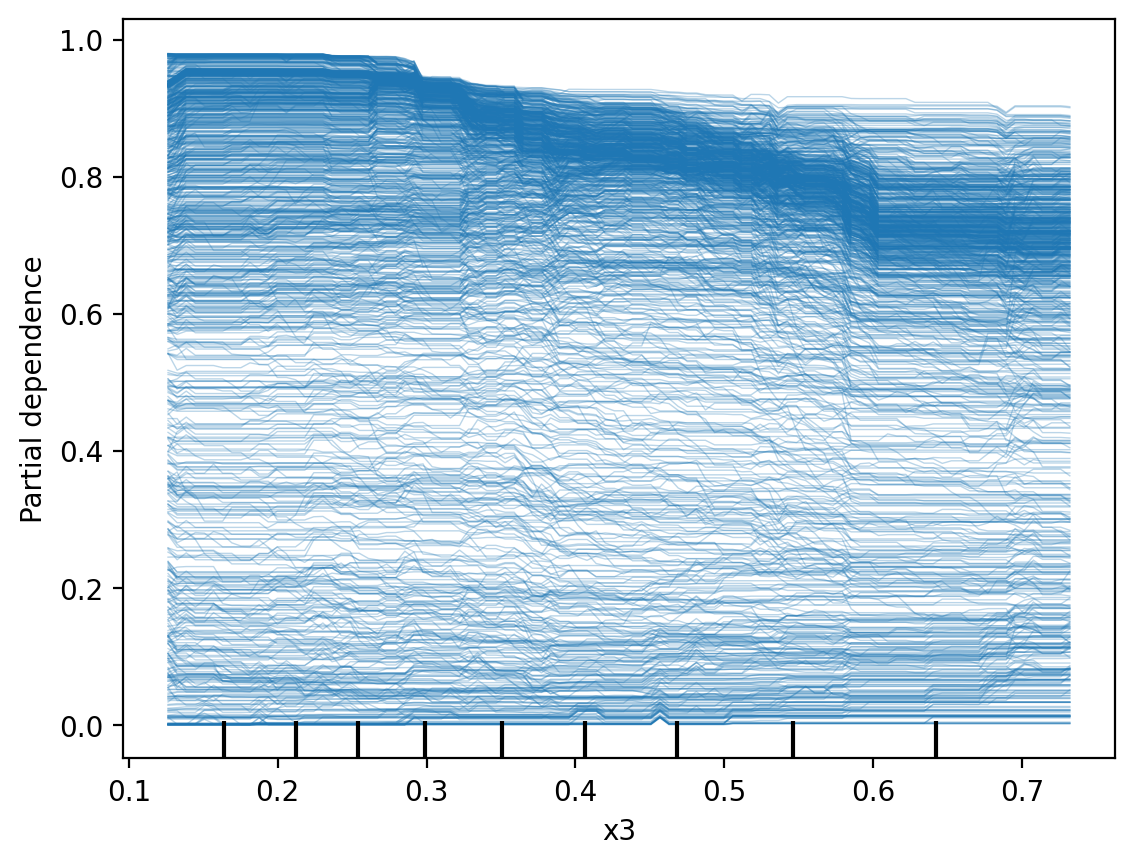

In [4]:

from sklearn.inspection import PartialDependenceDisplay


feature_idx = 3

PartialDependenceDisplay.from_estimator(rf, X_test, [feature_idx],
   kind='individual')

Хотя ICE очень доступны и понятны, они обладают рядом ограничений:

- Построение ICE использует предположение о независимости признаков;
- В случае большого количества объектов в наборе данных график ICE оказывается нечитаемым. Иногда ICE становится читаемее и информативнее, если раскрашивать кривые по, например, уровням какого-то признака или кластерам объектов.
- ICE не дает централизованной оценки, которую можно измерить. У этой проблемы есть решение — рассмотрение ICE в паре c PDP.

## Partial Dependence Plots (PDP)

**Partial Dependence Plot (PDP)** показывает среднее влияние признака на предсказание модели, усредняя по всем остальным признакам.

Математически PDP для признака $S$ определяется как:

$$f_S(x_S) = E_{X_C}[f(x_S, X_C)] = \int f(x_S, x_C) dP(x_C)$$

где:
- $x_S$ - значение интересующего признака (признаков)
- $X_C$ - остальные признаки
- $f$ - функция модели
- $P(x_C)$ - маргинальное распределение остальных признаков

**Алгоритм вычисления PDP:**

1. Для каждого значения $x_S$ из интересующего диапазона:
   - Зафиксировать $x_S$
   - Для каждого объекта из обучающей выборки заменить значение признака $S$ на $x_S$
   - Вычислить предсказания модели для всех модифицированных объектов
   - Усреднить предсказания

Partial Dependence plot является логическим продолжением ICE, а именно — усредняет его оценку. Это глобальная интерпретация и она также реализована в sklearn, в том числе в двумерном виде.

In [5]:
feature_idx_alpha = list(columns).index("Alpha")
feature_idx_length = list(columns).index("Length")
feature_idx_width = list(columns).index("Width")

pdp_alpha = partial_dependence(
    rf, X_train, features=[feature_idx_alpha],
    grid_resolution=50, kind='average'
)

pdp_length = partial_dependence(
    rf, X_train, features=[feature_idx_length],
    grid_resolution=50, kind='average'
)

pdp_width = partial_dependence(
    rf, X_train, features=[feature_idx_width],
    grid_resolution=50, kind='average'
)


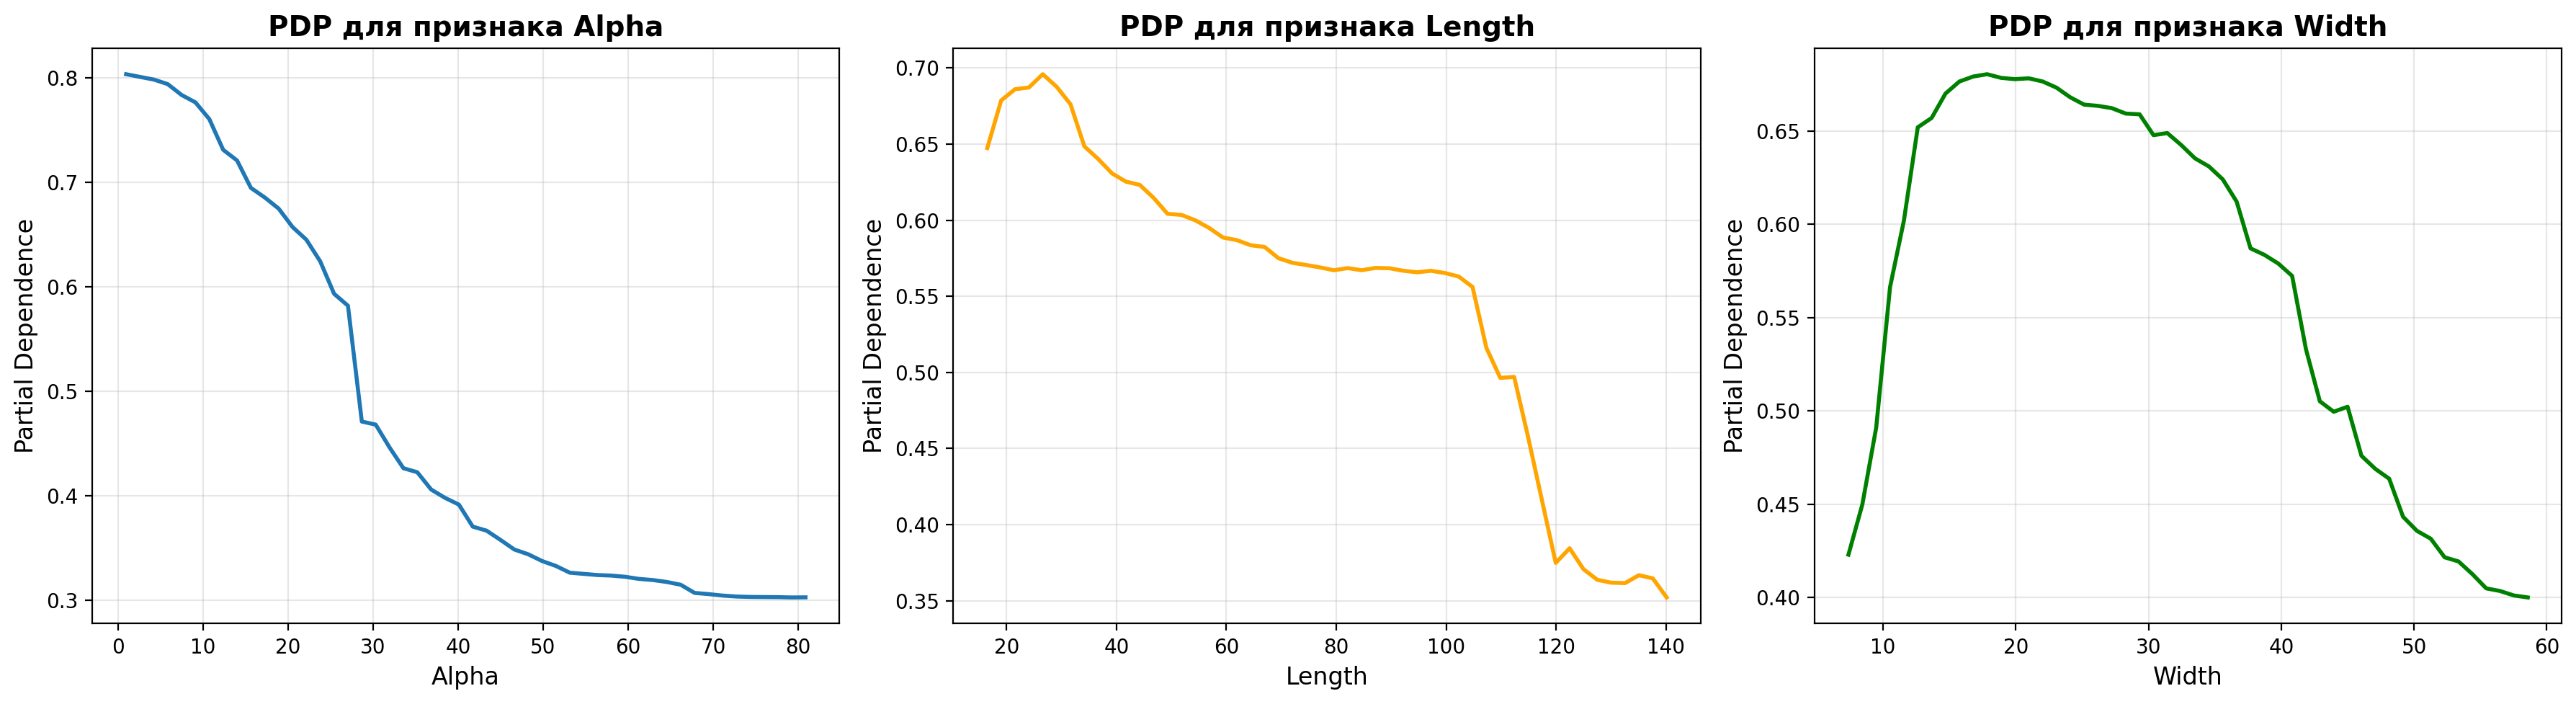

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(pdp_alpha['grid_values'][0], pdp_alpha['average'][0], linewidth=2)
axes[0].set_xlabel('Alpha', fontsize=12)
axes[0].set_ylabel('Partial Dependence', fontsize=12)
axes[0].set_title('PDP для признака Alpha', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pdp_length['grid_values'][0], pdp_length['average'][0], linewidth=2, color='orange')
axes[1].set_xlabel('Length', fontsize=12)
axes[1].set_ylabel('Partial Dependence', fontsize=12)
axes[1].set_title('PDP для признака Length', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(pdp_width['grid_values'][0], pdp_width['average'][0], linewidth=2, color='green')
axes[2].set_xlabel('Width', fontsize=12)
axes[2].set_ylabel('Partial Dependence', fontsize=12)
axes[2].set_title('PDP для признака Width', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


PDP позволяет также сделать дополнительные выводы о взаимодействии признаков между собой. Полностью прямые линии говорят, что взаимодействия нет (либо один признак вообще не имеет влияния в модели). Однако PDP никак не учитывает распределение признака по группам, и если для одной группы прогноз растет, а для другой падает, мы не увидим никакого влияния. Здесь возможным решением может быть построение графиков отдельно для разных групп или предварительный анализ ICE.

Задание: Постройте графики ICE, PDP для признаков LotFrontage, GarageArea  набора данных realestate из прошлогодних практик с учетом разбиения по районам (Neighborhood) и без него. Заметна ли проблема усреднения?

Кроме того, PDP также, как и  ICE предполагает независимость признаков, поэтому может приводить к некорректным выводам. 

In [7]:
# ICE и PDP для LotFrontage, GarageArea

data_re = pd.read_csv(pjoin(data_path, "realestate.txt"), sep="\t")
data_re = data_re.replace([np.inf, -np.inf], np.nan)

for col in data_re.columns:
    if data_re[col].dtype == "object":
        data_re[col] = data_re[col].fillna(data_re[col].mode()[0])
    else:
        data_re[col] = data_re[col].fillna(data_re[col].median())

X_re = data_re.drop("SalePrice", axis=1)
y_re = data_re["SalePrice"]

X_re_ohe = pd.get_dummies(X_re, drop_first=True)

X_train_re, X_test_re, y_train_re, y_test_re = train_test_split(
    X_re_ohe, y_re, test_size=0.3, random_state=42
)

rf_re = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_re.fit(X_train_re, y_train_re)

print("R2:", rf_re.score(X_test_re, y_test_re))

R2: 0.8183511586187381


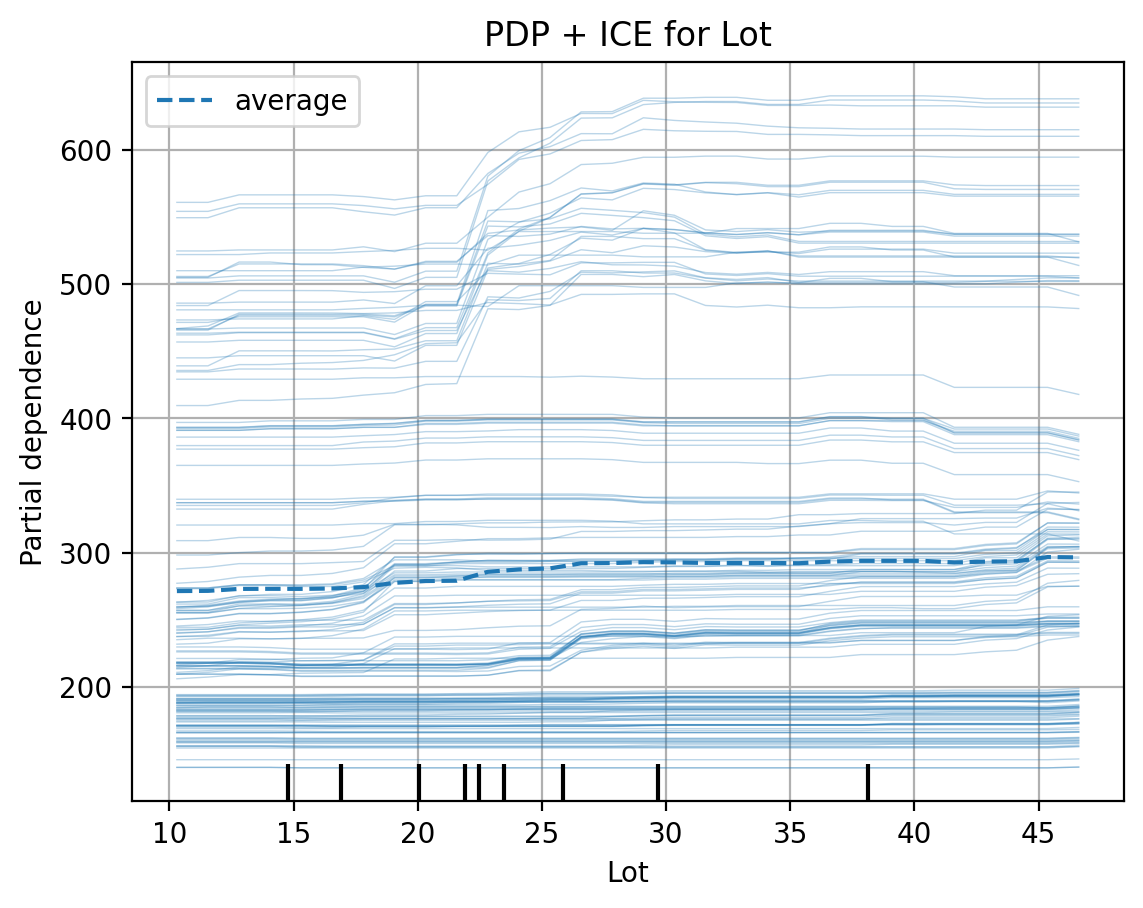

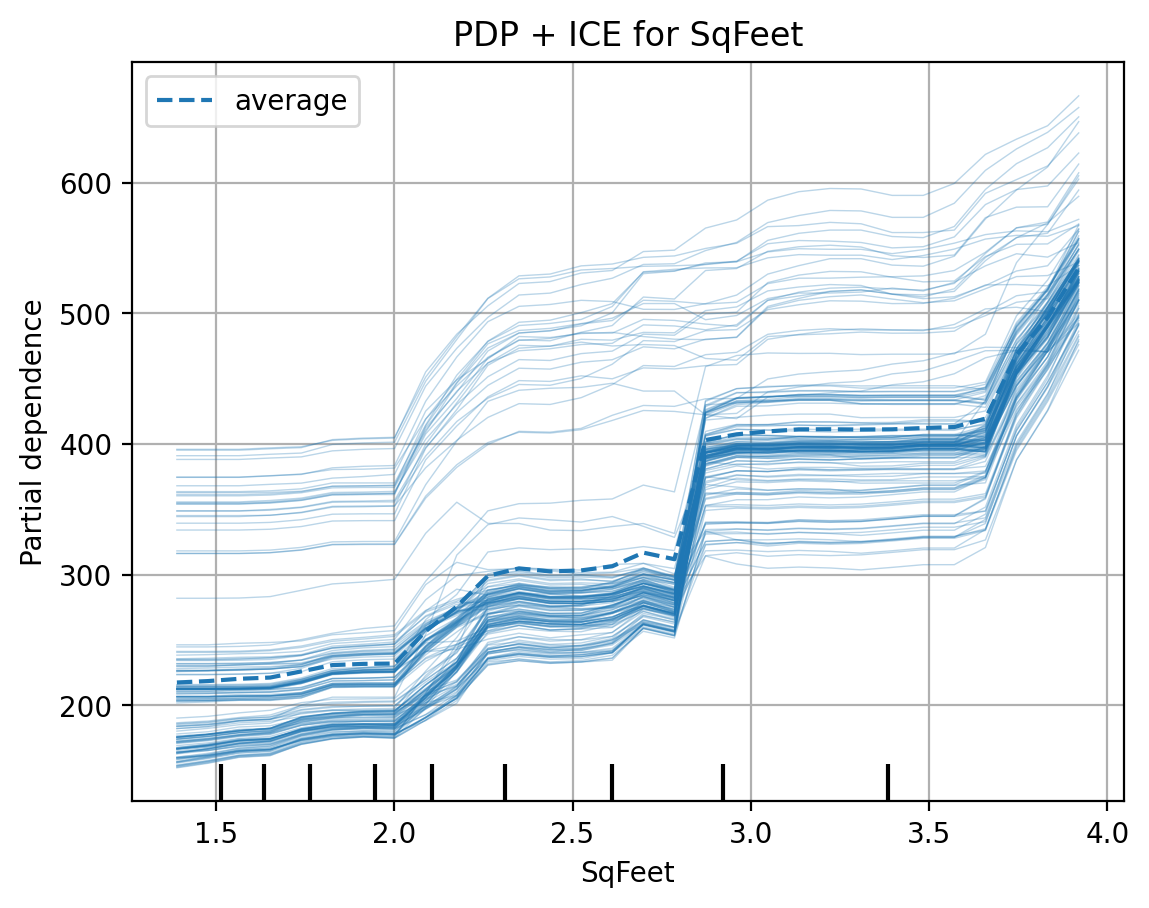

In [8]:
features = ["Lot", "SqFeet"]

for feature in features:
    PartialDependenceDisplay.from_estimator(
        rf_re,
        X_test_re,
        features=[feature],
        kind="both",
        grid_resolution=30
    )
    
    plt.title(f"PDP + ICE for {feature}")
    plt.grid()
    plt.show()

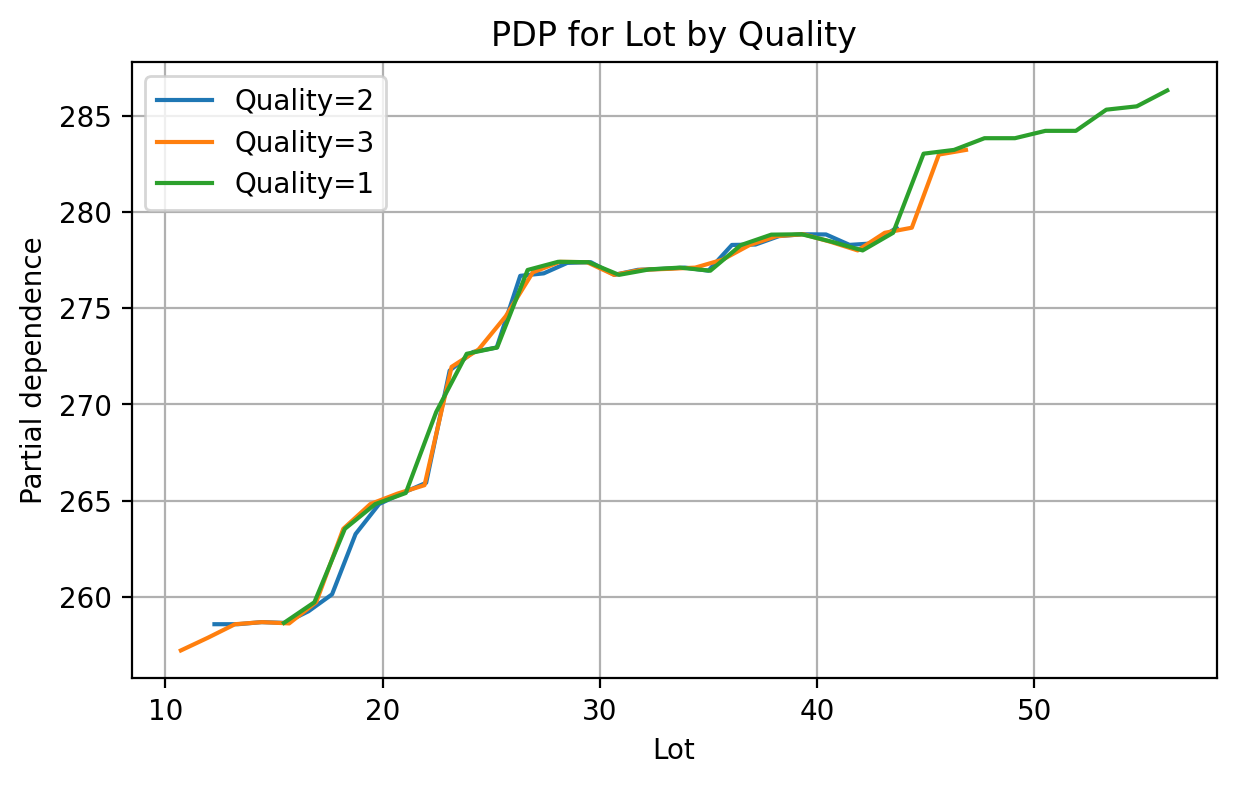

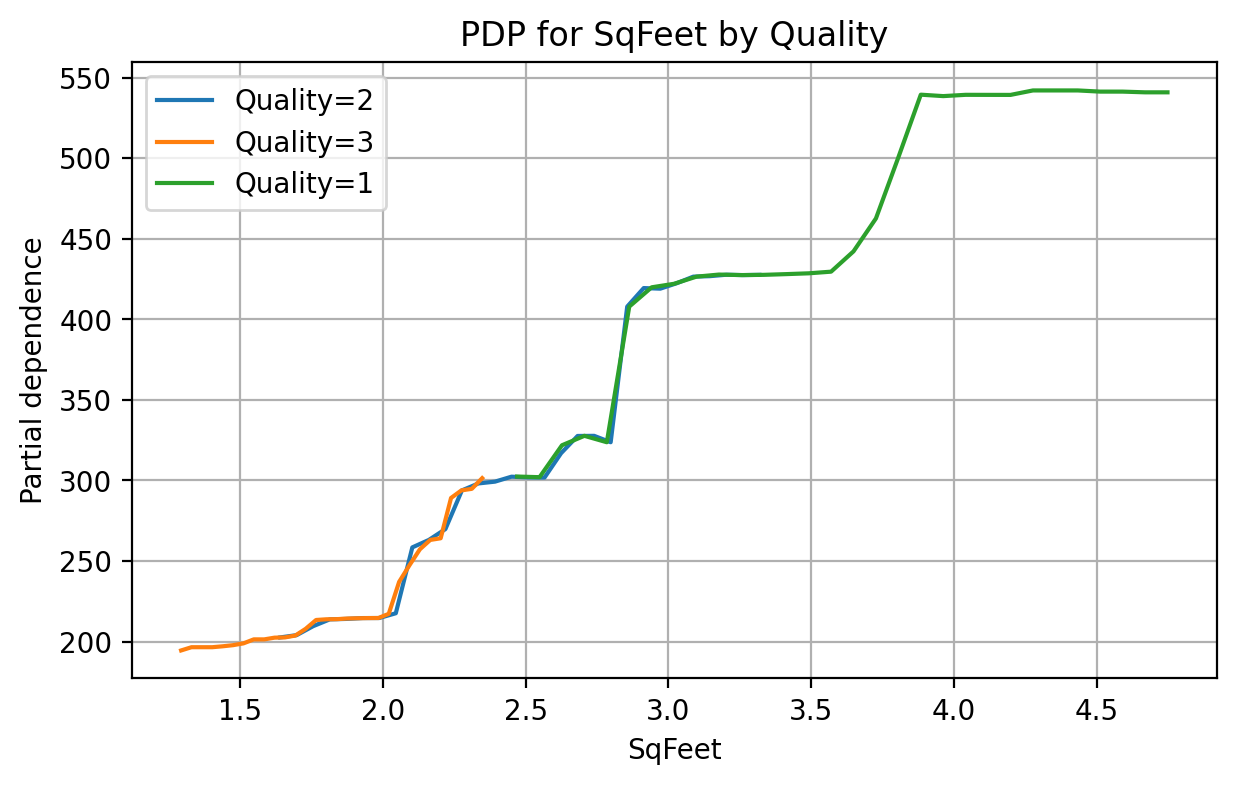

In [9]:
# PDP с разбиением по Quality (лень возвращаться к датасетам с Neighborhood, разбиваем тут по Quality)

group_col = "Quality"
top_groups = X_re[group_col].value_counts().head(4).index

for feature in features:
    plt.figure(figsize=(7, 4))

    for group in top_groups:
        idx = X_re[X_re[group_col] == group].index
        X_group = X_re_ohe.loc[idx]

        pdp = partial_dependence(
            rf_re,
            X_group,
            features=[feature],
            grid_resolution=30,
            kind="average"
        )

        plt.plot(
            pdp["grid_values"][0],
            pdp["average"][0],
            label=f"{group_col}={group}"
        )

    plt.title(f"PDP for {feature} by {group_col}")
    plt.xlabel(feature)
    plt.ylabel("Partial dependence")
    plt.legend()
    plt.grid()
    plt.show()

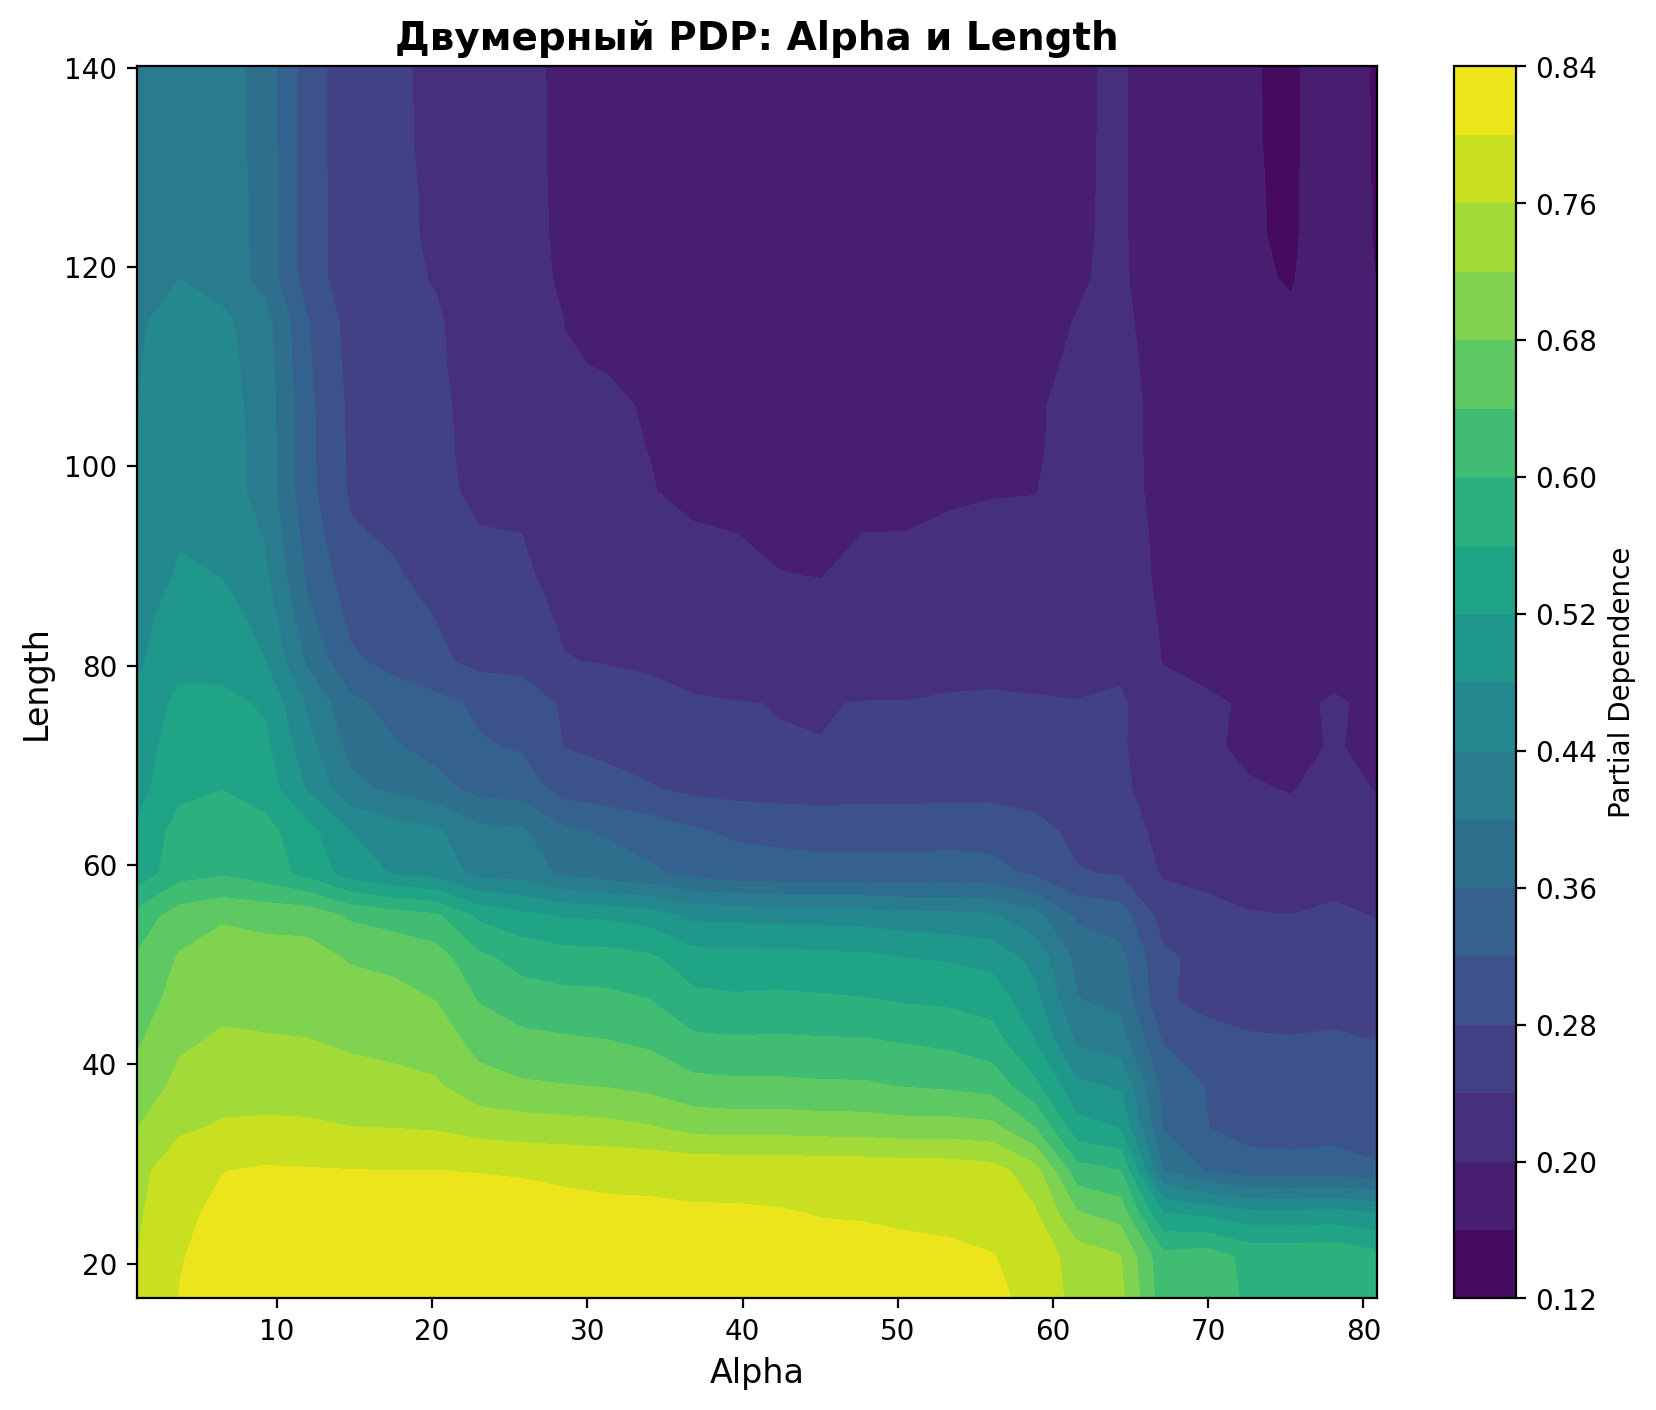

In [10]:
pdp_2d = partial_dependence(
    rf, X_train, features=[(feature_idx_alpha, feature_idx_length)],
    grid_resolution=30, kind='average'
)

fig, ax = plt.subplots(figsize=(10, 8))
grid_alpha = pdp_2d['grid_values'][0]
grid_length = pdp_2d['grid_values'][1]
pdp_values = pdp_2d['average'][0]

im = ax.contourf(grid_alpha, grid_length, pdp_values, levels=20, cmap='viridis')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Length', fontsize=12)
ax.set_title('Двумерный PDP: Alpha и Length', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Partial Dependence')
plt.show()


## Accumulated Local Effects (ALE)

**Accumulated Local Effects (ALE)** решает проблему PDP с коррелированными признаками, используя условное распределение вместо маргинального.

ALE для признака $j$ определяется как:

$$ALE_j(x) = \int_{x_{min,j}}^{x} E_{X_C|X_j=z}\left[\frac{\partial f}{\partial X_j}(z, X_C)\right] dz$$

где:
- $x_{min,j}$ - минимальное значение признака $j$
- $\frac{\partial f}{\partial X_j}$ - частная производная функции модели по признаку $j$
- Усреднение происходит по условному распределению $P(X_C | X_j = z)$

**Дискретные формулы для вычисления ALE:**

В дискретном виде алгоритм вычисления ALE выглядит следующим образом:

1. **Локальный эффект для интервала $k$**:
   $$\Delta_k = \frac{1}{N_k} \sum_{i: x_{i,j} \in [z_{k-1}, z_k]} [f(z_k, x_{C,i}) - f(z_{k-1}, x_{C,i})]$$
   
   где $N_k$ - количество объектов в интервале $[z_{k-1}, z_k]$, $x_{C,i}$ - значения остальных признаков для объекта $i$.

2. **Накопленный эффект**:
   $$ALE_k = \sum_{j=1}^{k} \Delta_j$$

3. **Центрированный ALE по среднему**:
   $$ALE_k^{centered} = ALE_k - \bar{ALE}$$
   
   где $\bar{ALE} = \frac{1}{K} \sum_{k=1}^{K} ALE_k$ - среднее значение ALE по всем интервалам.

**Алгоритм вычисления ALE:**

1. **Разбиение на интервалы**: Разделить диапазон признака $j$ на $K$ интервалов
2. **Вычисление локальных эффектов**: Для каждого интервала $[z_{k-1}, z_k]$:
   - Найти объекты, у которых значение признака $j$ попадает в интервал
   - Вычислить разницу предсказаний при изменении признака от $z_{k-1}$ до $z_k$
   - Усреднить по объектам в интервале
3. **Накопление**: Проинтегрировать (суммировать) локальные эффекты от начала диапазона
4. **Центрирование**: Вычесть среднее значение ALE из всех точек, чтобы среднее значение центрированного ALE было равно нулю. Это облегчает интерпретацию и сравнение эффектов разных признаков.

In [11]:
def compute_ale(model, X: np.ndarray, feature_idx: int, n_bins: int = 50, n_samples: int = 1000, centered: bool = True) -> tuple[np.ndarray, np.ndarray]:
    feature_values = X[:, feature_idx]
    min_val = feature_values.min()
    max_val = feature_values.max()
    
    quantiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(feature_values, quantiles)
    bin_edges[0] = min_val
    bin_edges[-1] = max_val
    
    ale_values = np.zeros(n_bins)
    ale_grid = np.zeros(n_bins)
    
    X_sample = X[np.random.choice(X.shape[0], min(n_samples, X.shape[0]), replace=False)]
    
    for k in range(n_bins):
        z_low = bin_edges[k]
        z_high = bin_edges[k + 1]
        ale_grid[k] = (z_low + z_high) / 2
        
        mask = (feature_values >= z_low) & (feature_values < z_high)
        if k == n_bins - 1:
            mask = (feature_values >= z_low) & (feature_values <= z_high)
        
        if mask.sum() == 0:
            continue
        
        X_low = X_sample.copy()
        X_high = X_sample.copy()
        X_low[:, feature_idx] = z_low
        X_high[:, feature_idx] = z_high
        
        pred_low = model.predict_proba(X_low)[:, 1]
        pred_high = model.predict_proba(X_high)[:, 1]
        
        local_effect = np.mean(pred_high - pred_low)
        ale_values[k] = local_effect
    
    ale_accumulated = np.cumsum(ale_values)
    
    if centered:
        ale_accumulated = ale_accumulated - np.mean(ale_accumulated)
    
    return ale_grid, ale_accumulated


In [12]:
ale_alpha_grid, ale_alpha_values = compute_ale(rf, X_train, feature_idx_alpha, n_bins=50)
ale_length_grid, ale_length_values = compute_ale(rf, X_train, feature_idx_length, n_bins=50)
ale_width_grid, ale_width_values = compute_ale(rf, X_train, feature_idx_width, n_bins=50)


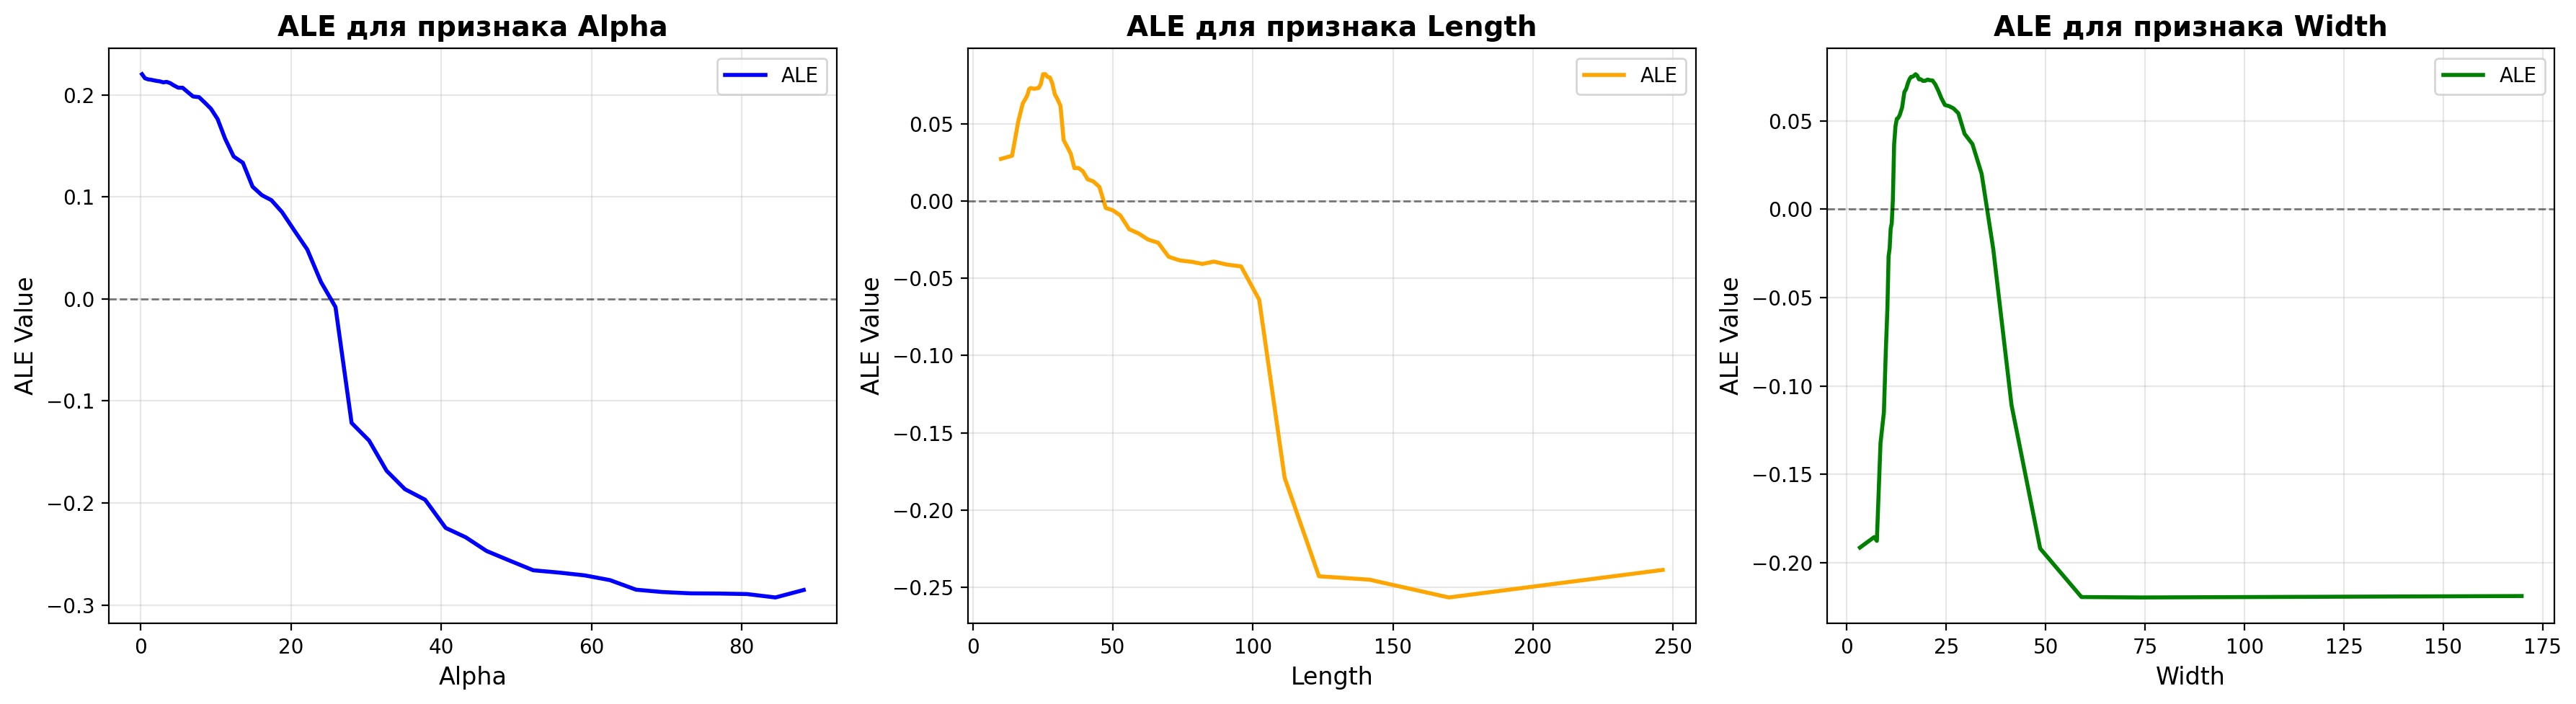

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ale_alpha_grid, ale_alpha_values, linewidth=2, color='blue', label='ALE')
axes[0].set_xlabel('Alpha', fontsize=12)
axes[0].set_ylabel('ALE Value', fontsize=12)
axes[0].set_title('ALE для признака Alpha', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ale_length_grid, ale_length_values, linewidth=2, color='orange', label='ALE')
axes[1].set_xlabel('Length', fontsize=12)
axes[1].set_ylabel('ALE Value', fontsize=12)
axes[1].set_title('ALE для признака Length', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(ale_width_grid, ale_width_values, linewidth=2, color='green', label='ALE')
axes[2].set_xlabel('Width', fontsize=12)
axes[2].set_ylabel('ALE Value', fontsize=12)
axes[2].set_title('ALE для признака Width', fontsize=14, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


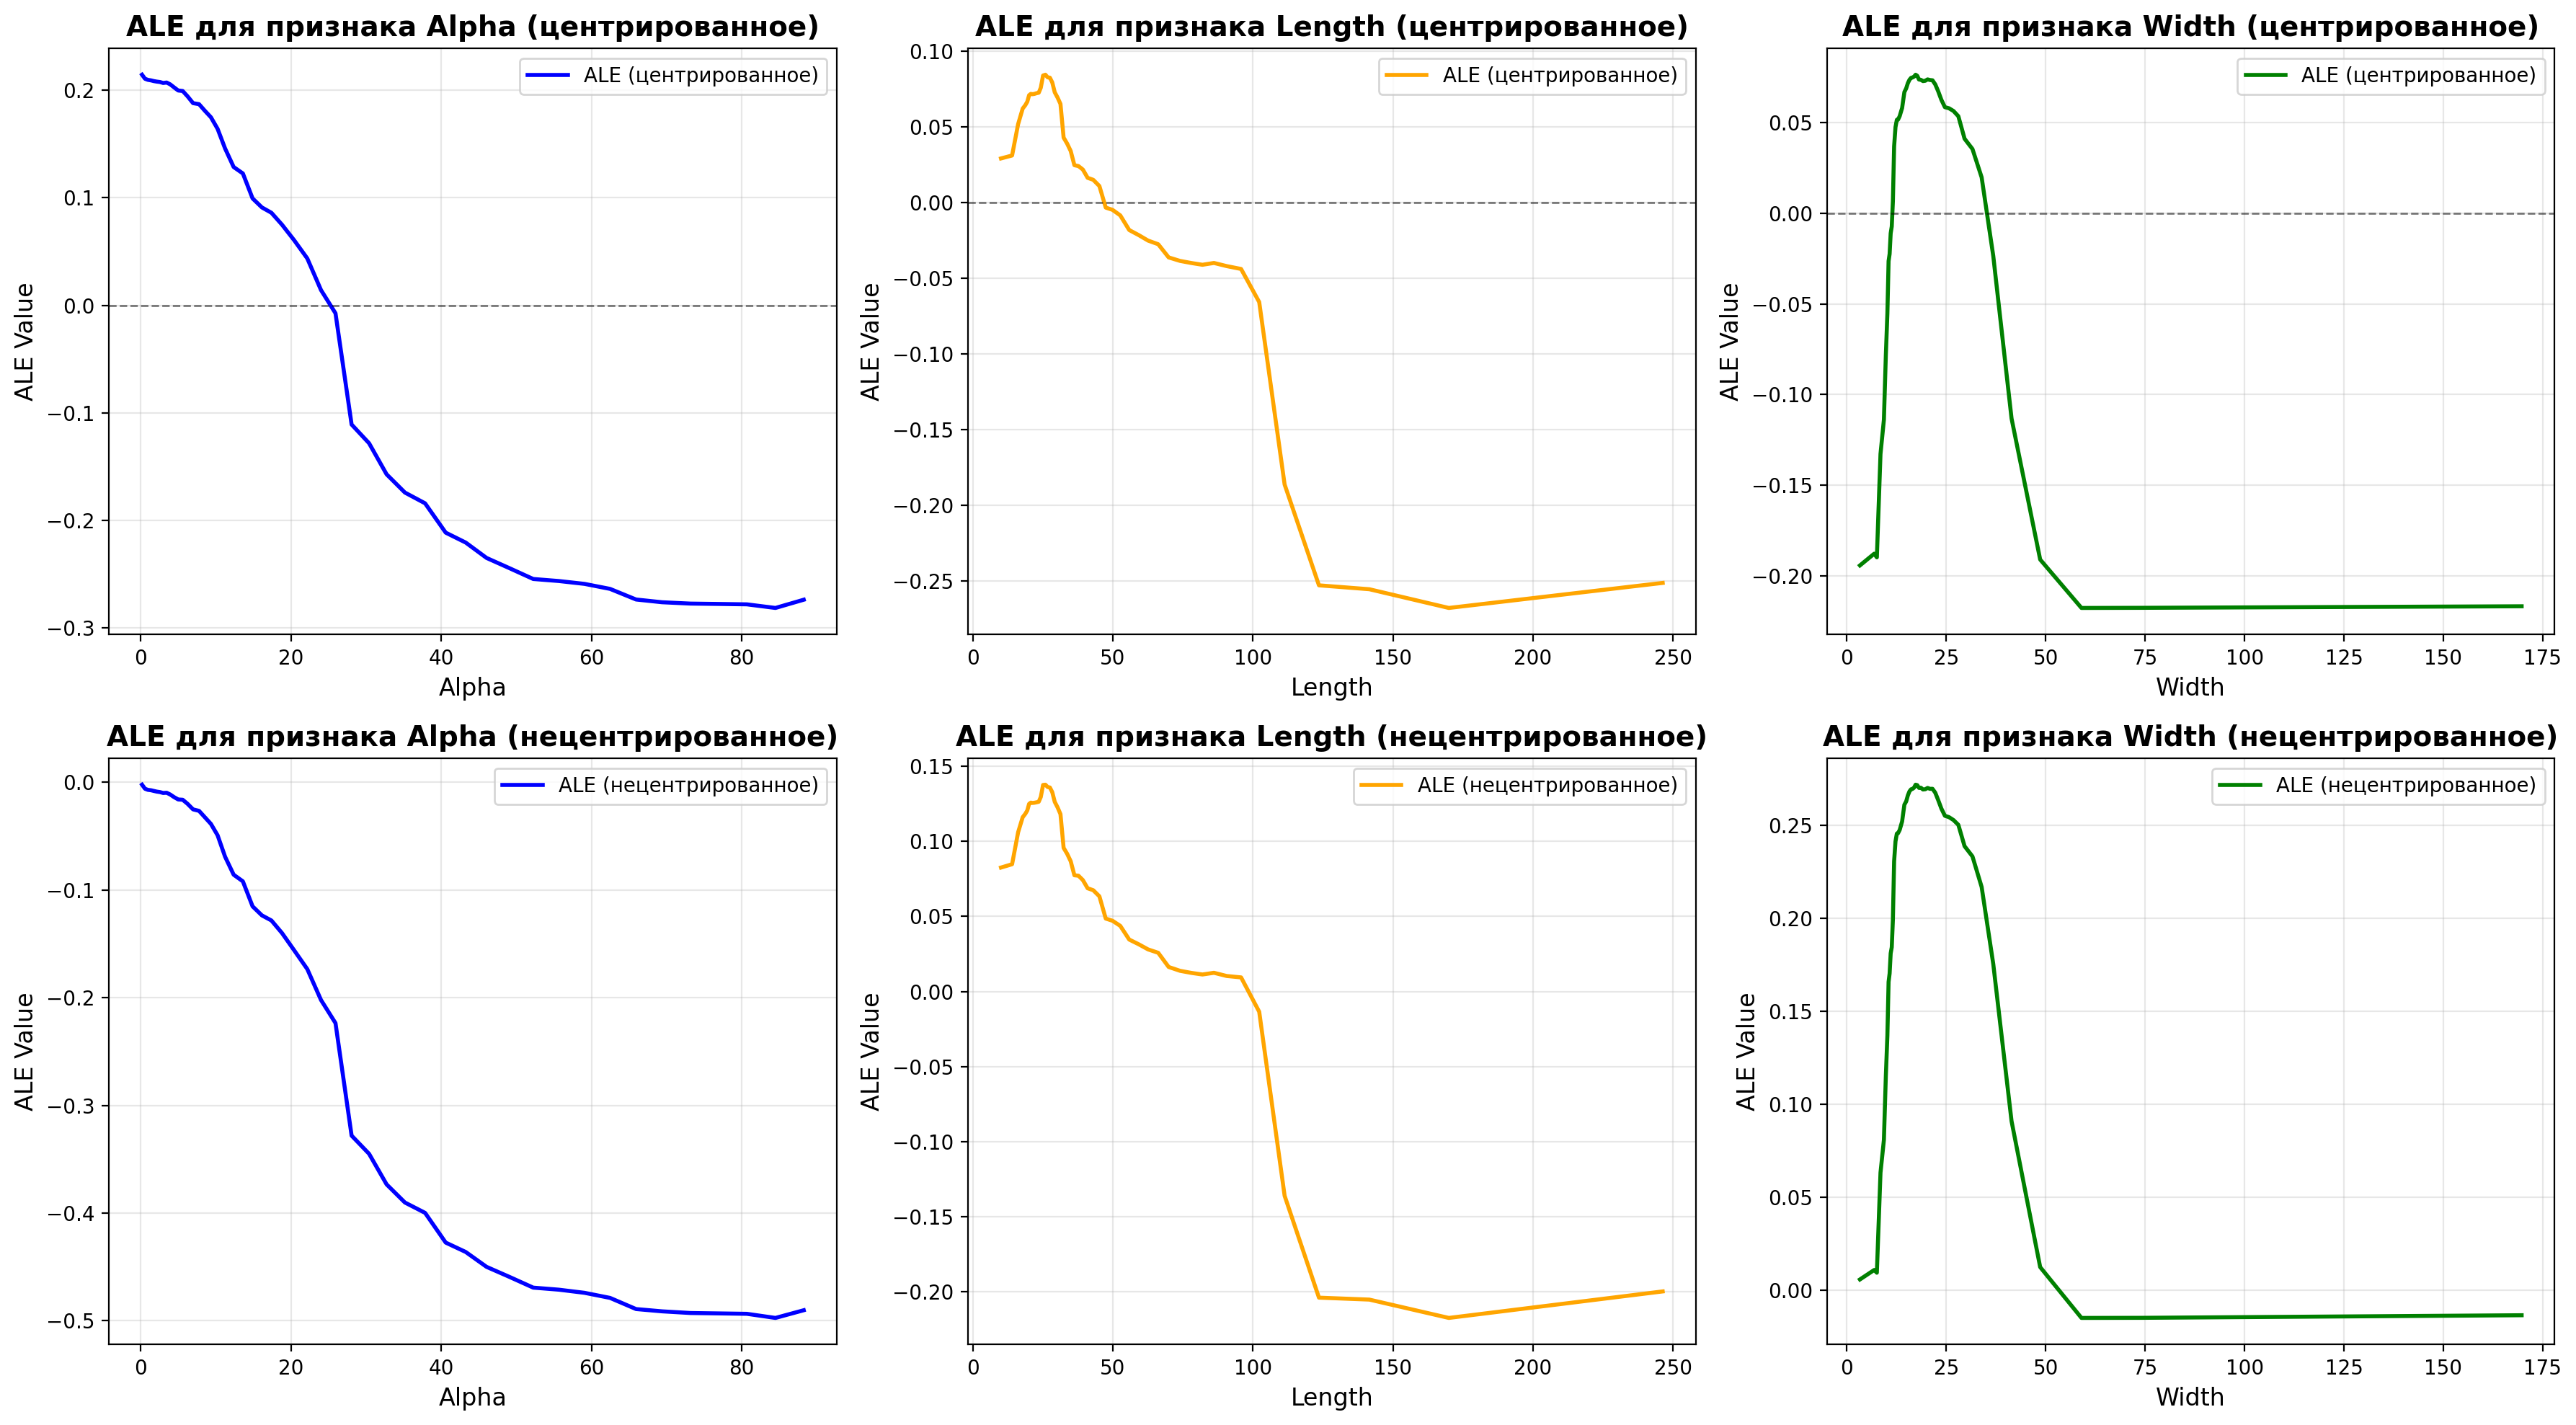

In [14]:
ale_alpha_grid_centered, ale_alpha_values_centered = compute_ale(rf, X_train, feature_idx_alpha, n_bins=50, centered=True)
ale_length_grid_centered, ale_length_values_centered = compute_ale(rf, X_train, feature_idx_length, n_bins=50, centered=True)
ale_width_grid_centered, ale_width_values_centered = compute_ale(rf, X_train, feature_idx_width, n_bins=50, centered=True)

ale_alpha_grid_uncentered, ale_alpha_values_uncentered = compute_ale(rf, X_train, feature_idx_alpha, n_bins=50, centered=False)
ale_length_grid_uncentered, ale_length_values_uncentered = compute_ale(rf, X_train, feature_idx_length, n_bins=50, centered=False)
ale_width_grid_uncentered, ale_width_values_uncentered = compute_ale(rf, X_train, feature_idx_width, n_bins=50, centered=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(ale_alpha_grid_centered, ale_alpha_values_centered, linewidth=2, color='blue', label='ALE (центрированное)')
axes[0, 0].set_xlabel('Alpha', fontsize=12)
axes[0, 0].set_ylabel('ALE Value', fontsize=12)
axes[0, 0].set_title('ALE для признака Alpha (центрированное)', fontsize=14, fontweight='bold')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ale_length_grid_centered, ale_length_values_centered, linewidth=2, color='orange', label='ALE (центрированное)')
axes[0, 1].set_xlabel('Length', fontsize=12)
axes[0, 1].set_ylabel('ALE Value', fontsize=12)
axes[0, 1].set_title('ALE для признака Length (центрированное)', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[0, 2].plot(ale_width_grid_centered, ale_width_values_centered, linewidth=2, color='green', label='ALE (центрированное)')
axes[0, 2].set_xlabel('Width', fontsize=12)
axes[0, 2].set_ylabel('ALE Value', fontsize=12)
axes[0, 2].set_title('ALE для признака Width (центрированное)', fontsize=14, fontweight='bold')
axes[0, 2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

axes[1, 0].plot(ale_alpha_grid_uncentered, ale_alpha_values_uncentered, linewidth=2, color='blue', label='ALE (нецентрированное)')
axes[1, 0].set_xlabel('Alpha', fontsize=12)
axes[1, 0].set_ylabel('ALE Value', fontsize=12)
axes[1, 0].set_title('ALE для признака Alpha (нецентрированное)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(ale_length_grid_uncentered, ale_length_values_uncentered, linewidth=2, color='orange', label='ALE (нецентрированное)')
axes[1, 1].set_xlabel('Length', fontsize=12)
axes[1, 1].set_ylabel('ALE Value', fontsize=12)
axes[1, 1].set_title('ALE для признака Length (нецентрированное)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[1, 2].plot(ale_width_grid_uncentered, ale_width_values_uncentered, linewidth=2, color='green', label='ALE (нецентрированное)')
axes[1, 2].set_xlabel('Width', fontsize=12)
axes[1, 2].set_ylabel('ALE Value', fontsize=12)
axes[1, 2].set_title('ALE для признака Width (нецентрированное)', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()


In [15]:
# !pip install -qU pyALE;

PyALE._ALE_generic:INFO: Continuous feature detected.


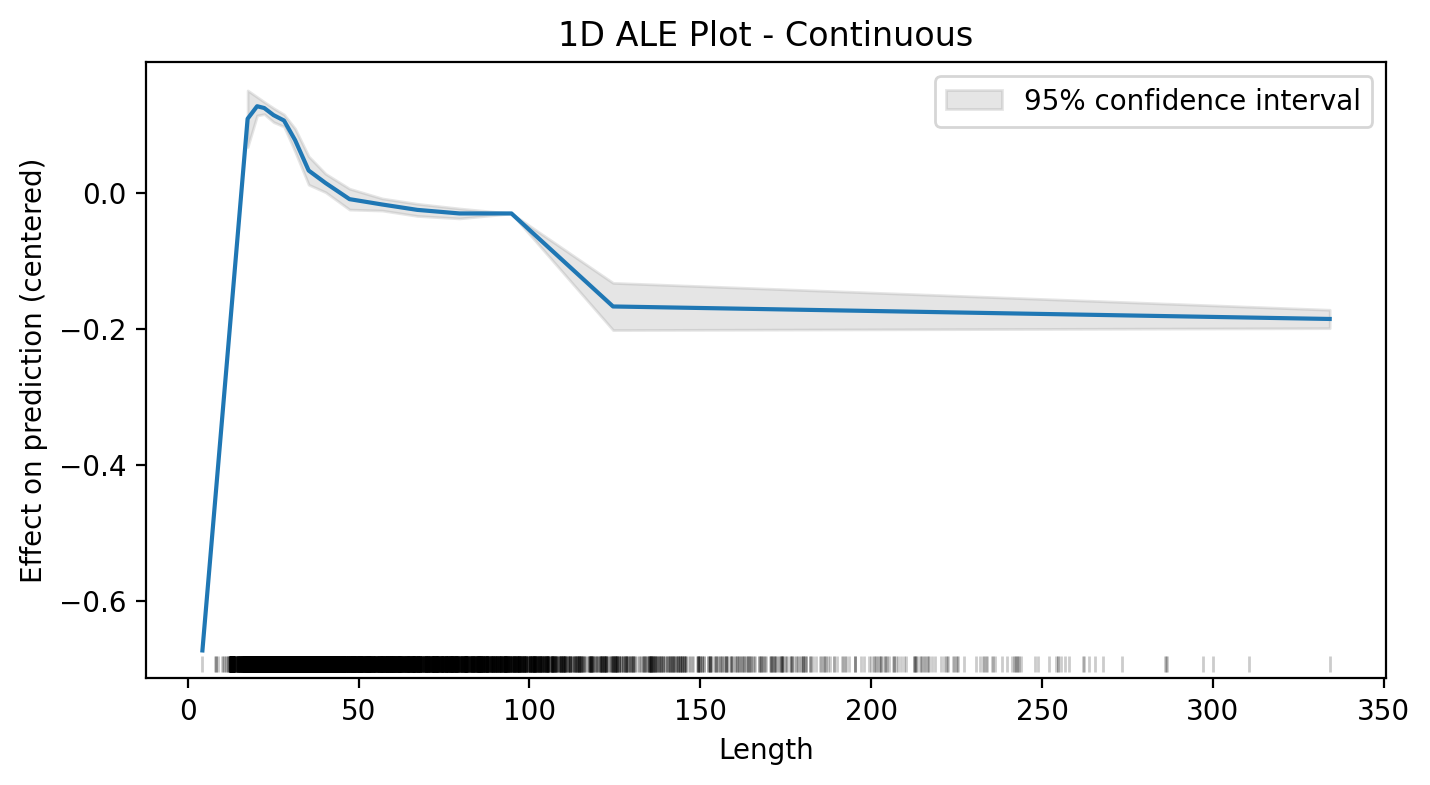

In [16]:
from PyALE import ale

## 1D - continuous - no CI
ale_eff = ale(
    X=pd.DataFrame(X_test,columns=columns), model=rf, feature=['Length'], grid_size=15,
)

PyALE._ALE_generic:INFO: Continuous feature detected.


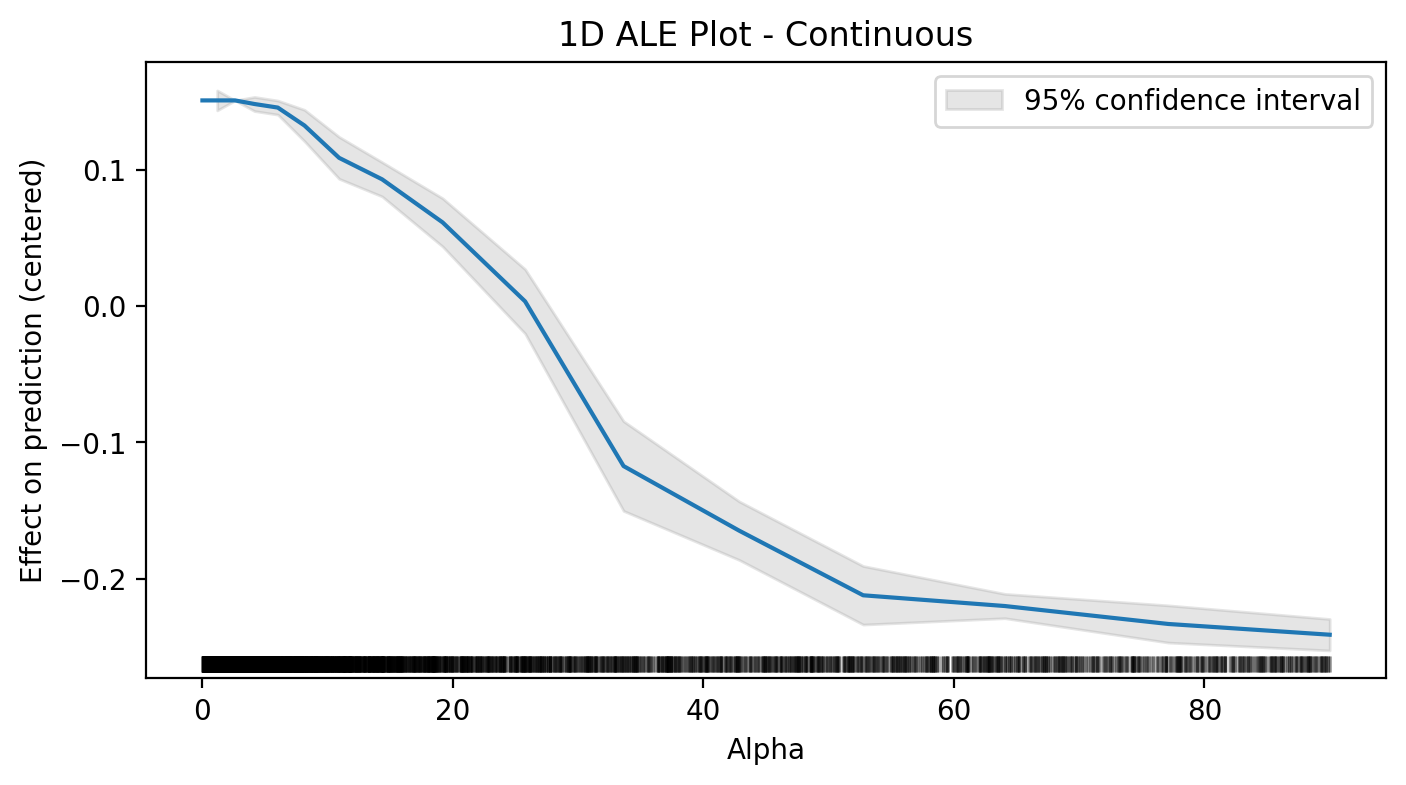

In [17]:
## 1D - continuous - no CI
ale_eff = ale(
    X=pd.DataFrame(X_test,columns=columns), model=rf, feature=['Alpha'], grid_size=15,
)

PyALE._ALE_generic:INFO: Continuous feature detected.


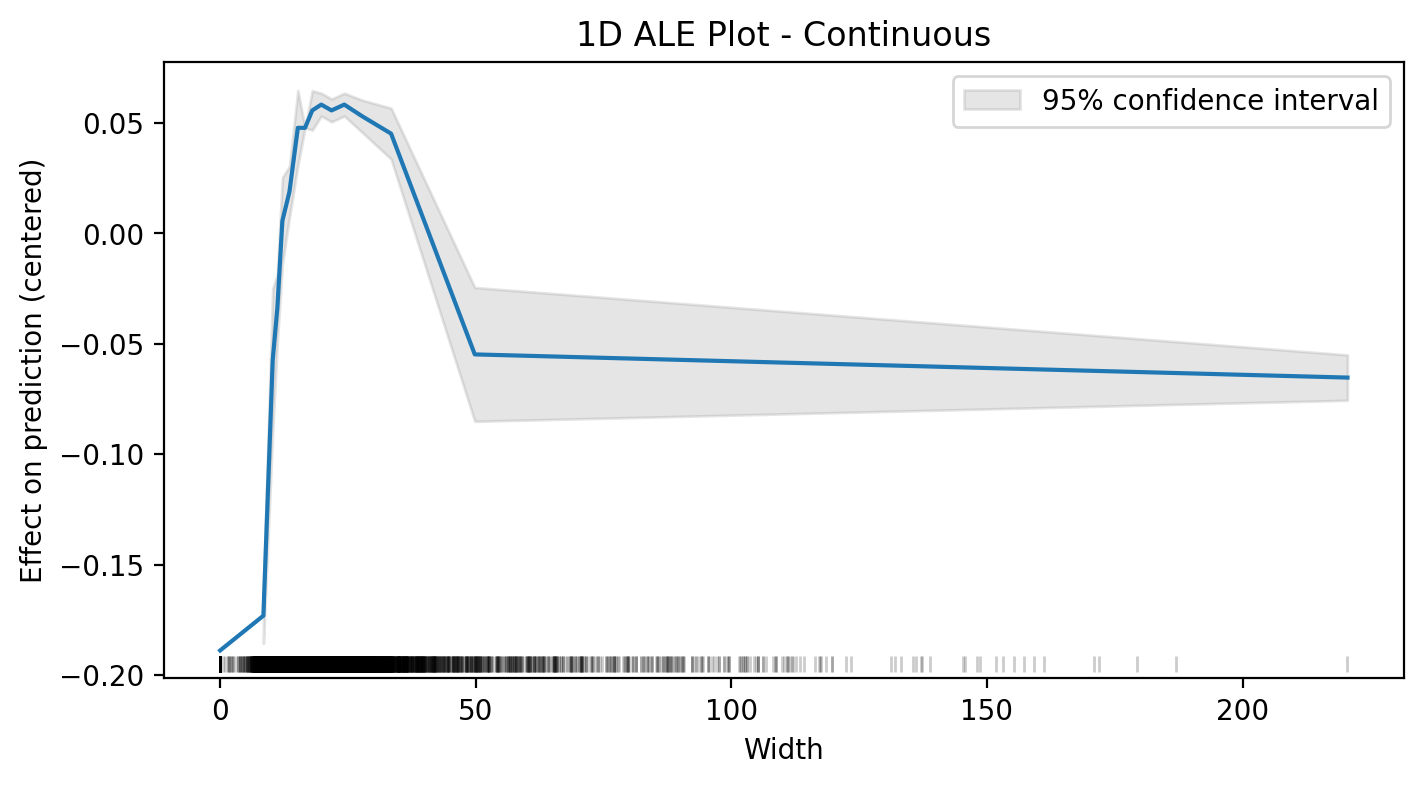

In [18]:
## 1D - continuous - no CI
ale_eff = ale(
    X=pd.DataFrame(X_test,columns=columns), model=rf, feature=['Width'], grid_size=15,
)

# LIME
Рассмотрим метод LIME (Local Interpretable Model Agnostic explanations), который позволяет построить интерпретацию для некоторого объясняемого объекта x* и его окрестности.
Для этого независимо от модели $a(x)$ для объекта вводится его объясняемое представление, и обучается модель $\hat a(x)$, которая строит предсказания для этих признаков. Чаще всего для этого используются довольно простые представления (например, мешок слов или суперпиксели). 
Для построения объясняющей модели:
1) Строится суррогатная выборка $X_{x*}^l = {(\hat x_i, y_i)}$ :
    1) создается l примеров $\hat x_i$ путем пертурбации исходных признаков, например, обнуления случайного количества единиц в интерпретируемом представлении $\hat x*$ объекта для текстов или  картинок. Вопрос, как в примере с текстом проходит обнуление?
    3) для каждого $\hat x_i$ делается переход в исходное пространство 
    4) получается $y = a(x_i)$

2) Обучается объясняющая модель:
   $$a_i = argmin_{b \in B} {\sum_{x_i} {\pi_{x*}(x_i)(a(x_i)-b((\hat x_i))^2+\sigma(b)}},$$
    - $B$ - cемейство объясняющих моделей, $\sigma(b)$ - ее сложность
    - $\pi_{x*}(x_i)$ - вес объекта, полученный с помощью некоторого ядра

Таким образом, объекты, близкие к x*, получают больший вес при обучении bб а удаленные - меньший. 

В качестве функции ошибки можно использовать и другую какую-то.
Пример - разреженные линейные представления (SLE), если использовать квадратичную функцию и $\sigma(b) = \infty[||w_b||_0 K]$ (Что за норма такая $||w_b||_0$?). Для интерпретации в таком случае достаточно вывести признаки с ненулевыми весами - так мы увидим, какие слова были использованы как самые "важные"

В итоге мы получаем довольно неплохую локальную интерпретацию, но глобально она будет, конечно же, не очень.

На практике обычно оптимизируется только часть, относящаяся к лоссу, а сложность контролируется за счет регуляризации объясняющей модели или RFE. 
Как это делается (для регуляризации): Задается большое $\lambda$, после чего оно постепенно уменьшается, пока не будет достигнуто K признаков с ненулевыми весами.

$\pi_{x*}(x_i)$ представляет собой функцию расстояния. Чаще всего используется гауссово ядро: 

$\pi_{x*}(x_i) = exp({-{d(x*, x_i)^2} \over {2\sigma^2}})$

Тут $\sigma$ - ширина ядра. Ее следует выбрать так, чтобы не размывать локальный контекст, но и не игнорировать информацию в дальних примерах.

## Таблицы

Как LIME работает с таблицами?

Во-первых, используются исходные признаки, не бинарные представления.

Во-вторых, выборки строятся путем вытягивания значения из нормального распределения со средним и стандартным отклонением, полученными из обучающего набора для каждой фичи независимо.
Кажется, что это не поможет нам строить интерпретацию для конкретного семпла. Но это работает, по крайней мере, частично. Вопрос: почему?

Для демонстрации используем уже знакомый нам датасет про дома

In [19]:
data_path = r"D:\spbu_ml_2026"
data = pd.read_csv(pjoin(data_path, "realestate.txt"), sep="\t")

data = data.select_dtypes(include=[np.number])
data = data.replace([np.inf, -np.inf], np.nan)
data = data.fillna(data.median())

X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

good_cols = X_train.columns[
    X_train.notna().all() &
    X_test.notna().all() &
    np.isfinite(X_train).all(axis=0) &
    np.isfinite(X_test).all(axis=0) &
    (X_train.std(axis=0) > 0)
]

X_train = X_train[good_cols].astype(float)
X_test = X_test[good_cols].astype(float)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("NaN in X_train:", np.isnan(X_train.values).sum())
print("NaN in X_test:", np.isnan(X_test.values).sum())
print("Number of removed columns:", X.shape[1] - X_train.shape[1])

X_train shape: (364, 11)
X_test shape: (157, 11)
NaN in X_train: 0
NaN in X_test: 0
Number of removed columns: 0


In [20]:
model = RandomForestRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", model.score(X_test, y_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.8183511586187381
RMSE: 66.5867493564924


In [21]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["SalePrice"],
    mode="regression",
    discretize_continuous=False
)

In [22]:
j = 5

exp = explainer.explain_instance(
    X_test.iloc[j].values,
    model.predict,
    num_features=6
)

exp.as_list()

[('SqFeet', 61.57339529988674),
 ('Quality', -32.468717610449666),
 ('Baths', 9.839147872505968),
 ('Year', 9.57486326616951),
 ('Lot', 8.80718650934496),
 ('Style', -4.394718392126645)]

Здесь положительное влияние показано справа, отрицательное - слева. Значения соответствуют весам линейной модели, аппроксимирующей наш случайный лес. Грубо говоря, если мы уменьшим year на 12, то и наше предсказание уменьшится на 31

Проверим, так ли

In [23]:
X_test.values[j]

array([1.7040e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00, 2.0000e+00,
       0.0000e+00, 1.9840e+03, 2.0000e+00, 3.0000e+00, 2.2583e+01,
       0.0000e+00])

In [24]:
print('Original prediction:', model.predict(X_test.values[j].reshape(1, -1)))
tmp = X_test.values[j].copy()
tmp[6] = 1980

Original prediction: [186.58848238]


In [25]:
print('Prediction removing some features:',  model.predict(tmp.reshape(1, -1)))
print('Difference:', model.predict(tmp.reshape(1, -1)) - model.predict(X_test.values[j].reshape(1, -1)))

Prediction removing some features: [186.58848238]
Difference: [0.]


Интересно, что для категориальных фичей мы снова можем построить более удачные объяснения. Как мы поняли, LIME требует бинарные представления. Как мы можем к ним придти? 

In [26]:
X_train.head()

,SqFeet,Beds,Baths,Air,Garage,Pool,Year,Quality,Style,Lot,Highway
231,2.101,3.0,3.0,0.0,2.0,0.0,1956.0,2.0,1.0,65.499,0.0
370,1.984,5.0,3.0,1.0,2.0,0.0,1961.0,2.0,1.0,22.047,0.0
94,2.705,3.0,3.0,1.0,3.0,0.0,1994.0,1.0,1.0,22.196,0.0
209,2.414,3.0,3.0,1.0,2.0,0.0,1914.0,2.0,7.0,24.357,0.0
497,1.672,3.0,1.0,1.0,2.0,0.0,1949.0,3.0,1.0,22.617,0.0


Мы можем задать, какие фичи у нас категориальные. 

In [27]:
categorical_features = ["Beds", "Baths", "Air", "Garage", "Pool", "Quality", "Style", "Highway"]
categorical_feature_ids = [1,2,3,4,5,7,8,10]

In [28]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, 
    feature_names=X_train.columns.values.tolist(),
    class_names=['SalePrice'], 
    categorical_features=categorical_feature_ids,
    categorical_names=categorical_features,
    verbose=True,
    mode='regression', 
    discretize_continuous=True
)
# Объясните тот же пример

Можно вообще извратиться и сделать за LIME бинаризацию. 

In [29]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoder.fit(X_train[categorical_features])
cat_df = pd.DataFrame(
    encoder.transform(X_train[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)
X_train_ohe = pd.concat([X_train[["SqFeet","Year", "Lot"]], cat_df], axis=1)

In [30]:
X_train_ohe.head()

,SqFeet,Year,Lot,Beds_2.0,Beds_3.0,Beds_4.0,Beds_5.0,Beds_6.0,Beds_7.0,Baths_2.0,...,Quality_2.0,Quality_3.0,Style_2.0,Style_3.0,Style_4.0,Style_5.0,Style_6.0,Style_7.0,Style_11.0,Highway_1.0
231,2.101,1956.0,65.499,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
370,1.984,1961.0,22.047,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
94,2.705,1994.0,22.196,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
209,2.414,1914.0,24.357,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
497,1.672,1949.0,22.617,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
cat_df = pd.DataFrame(
    encoder.transform(X_test[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)
X_test_ohe = pd.concat([X_test[["SqFeet","Year", "Lot"]], cat_df], axis=1)

In [32]:
encoder.get_feature_names_out()

array(['Beds_2.0', 'Beds_3.0', 'Beds_4.0', 'Beds_5.0', 'Beds_6.0',
       'Beds_7.0', 'Baths_2.0', 'Baths_3.0', 'Baths_4.0', 'Baths_5.0',
       'Baths_6.0', 'Baths_7.0', 'Air_1.0', 'Garage_1.0', 'Garage_2.0',
       'Garage_3.0', 'Garage_4.0', 'Garage_5.0', 'Garage_7.0', 'Pool_1.0',
       'Quality_2.0', 'Quality_3.0', 'Style_2.0', 'Style_3.0',
       'Style_4.0', 'Style_5.0', 'Style_6.0', 'Style_7.0', 'Style_11.0',
       'Highway_1.0'], dtype=object)

In [33]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train_ohe, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
# Настройте explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_ohe.values, 
    feature_names=X_train_ohe.columns.values.tolist(),
    class_names=['SalePrice'], 
    verbose=True, 
    mode='regression', 
    discretize_continuous=True
)

In [35]:
# Постройте интерпретацию для 5 семпла (id = 4)
j = 5
exp = explainer.explain_instance(X_train_ohe.values[j], model.predict, num_features=8)

Intercept 340.0216124659299
Prediction_local [218.78549299]
Right: 168.3549999999999


In [36]:
pd.DataFrame(exp.as_list(), columns=["feature", "weight"])

,feature,weight
0,1.70 < SqFeet <= 2.06,-86.897971
1,Baths_7.0 <= 0.00,38.610211
2,Garage_7.0 <= 0.00,-37.910901
3,Year > 1980.00,34.245259
4,Garage_5.0 <= 0.00,-21.241207
5,Baths_3.0 <= 0.00,-19.219513
6,0.00 < Quality_2.0 <= 1.00,-17.616705
7,Style_11.0 <= 0.00,-11.205293


Мы можем также задать ширину ядра и его вид.

**Задание**: Напишите свои ядра, берущие на вход расстояния и возвращающие значения от 0 до 1. Замените ядро по умолчанию. 

In [37]:
def gaussian_kernel(distances, kernel_width):
    return np.exp(-(distances ** 2) / (2 * kernel_width ** 2))


def exponential_kernel(distances, kernel_width):
    return np.exp(-distances / kernel_width)


def triangular_kernel(distances, kernel_width):
    weights = 1 - distances / kernel_width
    return np.maximum(0, weights)


def uniform_kernel(distances, kernel_width):
    return (distances <= kernel_width).astype(float)

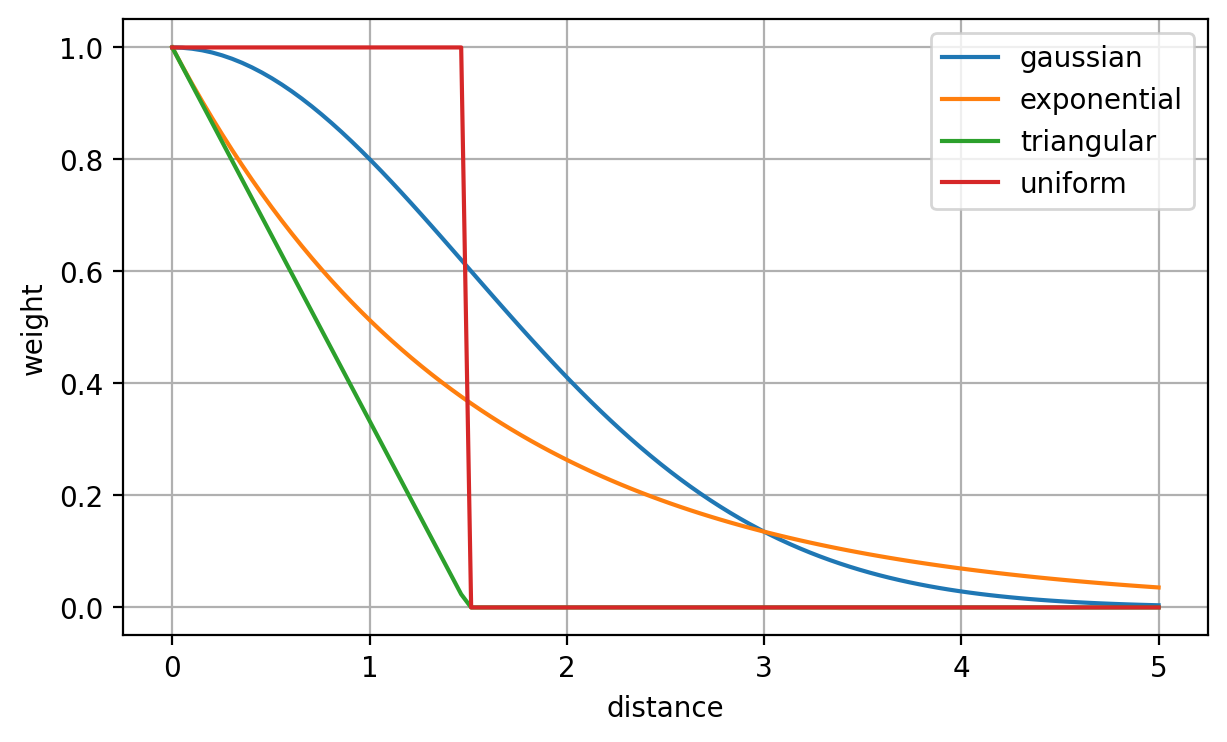

In [38]:
distances = np.linspace(0, 5, 100)
kernel_width = 1.5

plt.figure(figsize=(7, 4))

plt.plot(distances, gaussian_kernel(distances, kernel_width), label="gaussian")
plt.plot(distances, exponential_kernel(distances, kernel_width), label="exponential")
plt.plot(distances, triangular_kernel(distances, kernel_width), label="triangular")
plt.plot(distances, uniform_kernel(distances, kernel_width), label="uniform")

plt.xlabel("distance")
plt.ylabel("weight")
plt.legend()
plt.grid()
plt.show()

In [39]:
explainer_custom_kernel = lime.lime_tabular.LimeTabularExplainer(
    X_train_ohe.values,
    feature_names=X_train_ohe.columns.values.tolist(),
    class_names=["SalePrice"],
    mode="regression",
    discretize_continuous=True,
    kernel_width=1.5,
    kernel=triangular_kernel
)

j = 5

exp_custom = explainer_custom_kernel.explain_instance(
    X_train_ohe.values[j],
    model.predict,
    num_features=8
)

pd.DataFrame(exp_custom.as_list(), columns=["feature", "weight"])

,feature,weight
0,1.70 < SqFeet <= 2.06,-18.794513
1,Style_2.0 <= 0.00,-10.714658
2,0.00 < Baths_2.0 <= 1.00,-8.060437
3,Baths_4.0 <= 0.00,-1.325951
4,22.05 < Lot <= 26.61,-0.537148
5,Beds_2.0 <= 0.00,0.487336
6,Year > 1980.00,-0.345860
7,Style_3.0 > 0.00,-0.024975


## Тексты

Также рассмотрим интерпретацию для классификации новостей на две группы - атеизм и христианство.

In [40]:
from sklearn.datasets import fetch_20newsgroups
categories = ['alt.atheism', 'soc.religion.christian']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)
class_names = ['atheism', 'christian']

Векторизуем тексты с помощью TF-IDF

In [41]:
vectorizer = TfidfVectorizer(lowercase=False)
train_vectors = vectorizer.fit_transform(newsgroups_train.data)
test_vectors =  vectorizer.transform(newsgroups_test.data)# сделайте то же самое и для теста

In [42]:
rf = RandomForestClassifier().fit(train_vectors, newsgroups_train.target) # Обучите случайный лес

In [43]:
pred = rf.predict(test_vectors)
f1_score(newsgroups_test.target, pred, average='binary')

0.915606936416185

In [44]:
from sklearn.pipeline import make_pipeline
c = make_pipeline(vectorizer, rf)

In [45]:
print(c.predict_proba([newsgroups_test.data[0]]))

[[0.25 0.75]]


In [46]:
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=class_names)

In [47]:
idx = 83
exp = explainer.explain_instance(newsgroups_test.data[idx], c.predict_proba, num_features=6)
print('Document id: %d' % idx)
print('Probability(christian) =', c.predict_proba([newsgroups_test.data[idx]])[0,1])
print('True class: %s' % class_names[newsgroups_test.target[idx]])

Document id: 83
Probability(christian) = 0.46
True class: atheism


In [48]:
exp.as_list()

[(np.str_('Posting'), -0.13135937098562483),
 (np.str_('Host'), -0.13131446508667774),
 (np.str_('NNTP'), -0.10877711451684088),
 (np.str_('Subject'), 0.019975241490638965),
 (np.str_('edu'), -0.015933096418517728),
 (np.str_('post'), -0.015858831913693125)]

Посмотрим, сохраняется ли ситуация с изменением фичей. Тут ожидание следующее - вероятность увеличится на 0.3, если мы уберем из текста слова Host и Posting.

In [49]:
print('Original prediction:', rf.predict_proba(test_vectors[idx])[0,1])
tmp = test_vectors[idx].copy()
tmp[0,vectorizer.vocabulary_['Posting']] = 0
tmp[0,vectorizer.vocabulary_['Host']] = 0
print('Prediction removing some features:', rf.predict_proba(tmp)[0,1])
print('Difference:', rf.predict_proba(tmp)[0,1] - rf.predict_proba(test_vectors[idx])[0,1])

Original prediction: 0.46
Prediction removing some features: 0.7
Difference: 0.23999999999999994


Для текстов мы можем еще и посмотреть на самые важные слова:

In [50]:
# exp.show_in_notebook(text=True)

Судя по всему, на самом деле моделька смотрит на мусор типа заголовков или частых слов. Проверим, так ли это для какого-то другого примера:

In [51]:
idx = 34

exp = explainer.explain_instance(
    newsgroups_test.data[idx],
    c.predict_proba,
    num_features=6
)

print('Document id: %d' % idx)
print('Probability(christian) =', c.predict_proba([newsgroups_test.data[idx]])[0, 1])
print('True class: %s' % class_names[newsgroups_test.target[idx]])

pd.DataFrame(exp.as_list(), columns=["word", "weight"])

Document id: 34
Probability(christian) = 0.8
True class: christian


,word,weight
0,athos,0.065301
1,article,-0.051793
2,rutgers,0.044278
3,In,-0.044138
4,writes,-0.036286
5,said,-0.027256


Плюсы: 
- Можно поменять предсказывающую модель, но все еще использовать ту же объясняющую
- Легко применить, работает с разными видами данных
  
Минусы:
- Для табличных данных очень сложно выбрать ядро, да и вообще выбор ядра может значительно поменять интерпретацию.
- Сложность объяснения должна быть выбрана заранее
- Нестабильный

**Задание(*):**
У вас есть все составляющие LIME - ядра, алгоритм, кодировка фичей, loess с прошлой пары. Не хватает только кода с семплированием.
Напишите свой класс Lime для регрессии и таблиц, который с помощью линейной регрессии и заданного ядра строит интерпретацию. В качестве сложности используйте способ с регуляризацией (можете LARS). При вызове он должен вернуть коэффициенты регрессии, использованные для интерпретации. Не забудьте отшкалиировать фичи. В качестве метрики используйте евклидову.
Сделайте упрощенное семплирование - только нормальное распределение и дискретное по частотности категорий.

In [52]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

class LIME:
    def __init__(
        self,
        train_df,
        kernel,
        kernel_width=1.0,
        categorical_features=None,
        n_samples=1000,
        random_state=42
    ):
        self.train_df = train_df.copy()
        self.kernel = kernel
        self.kernel_width = kernel_width
        self.categorical_features = categorical_features or []
        self.n_samples = n_samples
        self.random_state = random_state
        self.rng = np.random.RandomState(random_state)
        
        self.numeric_features = [
            col for col in self.train_df.columns
            if col not in self.categorical_features
        ]
        
        self.numeric_means = self.train_df[self.numeric_features].mean()
        self.numeric_stds = self.train_df[self.numeric_features].std().replace(0, 1)
        
        self.category_probs = {}
        for col in self.categorical_features:
            self.category_probs[col] = self.train_df[col].value_counts(normalize=True)
        
        train_encoded = self._encode(self.train_df)
        self.encoded_columns = train_encoded.columns
        
        self.scaler = StandardScaler()
        self.scaler.fit(train_encoded)

    def _encode(self, df):
        df_encoded = pd.get_dummies(
            df,
            columns=self.categorical_features,
            drop_first=False
        )
        
        if hasattr(self, "encoded_columns"):
            df_encoded = df_encoded.reindex(
                columns=self.encoded_columns,
                fill_value=0
            )
            
        return df_encoded

    def _generate_sample(self, instance):
        rows = []

        for _ in range(self.n_samples):
            row = {}

            for col in self.numeric_features:
                row[col] = self.rng.normal(
                    self.numeric_means[col],
                    self.numeric_stds[col]
                )

            for col in self.categorical_features:
                probs = self.category_probs[col]
                row[col] = self.rng.choice(
                    probs.index,
                    p=probs.values
                )

            rows.append(row)

        sample = pd.DataFrame(rows)

        sample.iloc[0] = instance[self.train_df.columns].values

        return sample
        
    def explain(self, instance, prediction, num_features=5):
        if isinstance(instance, pd.Series):
            instance_df = pd.DataFrame([instance])
        else:
            instance_df = pd.DataFrame([instance], columns=self.train_df.columns)

        sample = self._generate_sample(instance_df.iloc[0])

        sample_encoded = self._encode(sample)
        instance_encoded = self._encode(instance_df)

        sample_scaled = self.scaler.transform(sample_encoded)
        instance_scaled = self.scaler.transform(instance_encoded)

        distances = np.linalg.norm(
            sample_scaled - instance_scaled,
            axis=1
        )

        weights = self.kernel(distances, self.kernel_width)

        y_sample = prediction(sample)

        alpha = 10.0
        best_model = None

        for _ in range(30):
            local_model = Lasso(alpha=alpha, max_iter=10000)
            local_model.fit(
                sample_scaled,
                y_sample,
                sample_weight=weights
            )

            non_zero = np.sum(local_model.coef_ != 0)
            best_model = local_model

            if non_zero >= num_features:
                break

            alpha = alpha / 2

        coefs = pd.DataFrame({
            "feature": self.encoded_columns,
            "coef": best_model.coef_
        })

        coefs["abs_coef"] = coefs["coef"].abs()

        coefs = (
            coefs[coefs["coef"] != 0]
            .sort_values("abs_coef", ascending=False)
            .head(num_features)
            .drop(columns="abs_coef")
        )

        return coefs

In [53]:
def gaussian_kernel(distances, kernel_width):
    return np.exp(-(distances ** 2) / (2 * kernel_width ** 2))

In [54]:
lime_custom = LIME(
    train_df=X_train_ohe,
    kernel=gaussian_kernel,
    kernel_width=1.0,
    categorical_features=[],
    n_samples=1000,
    random_state=42
)

j = 5

explanation = lime_custom.explain(
    instance=X_test_ohe.iloc[j],
    prediction=model.predict,
    num_features=6
)

explanation

,feature,coef
0,SqFeet,92.718351
23,Quality_2.0,-36.823029
5,Beds_4.0,-15.224293
26,Style_3.0,-12.319014
1,Year,3.771426
19,Garage_4.0,-2.662485


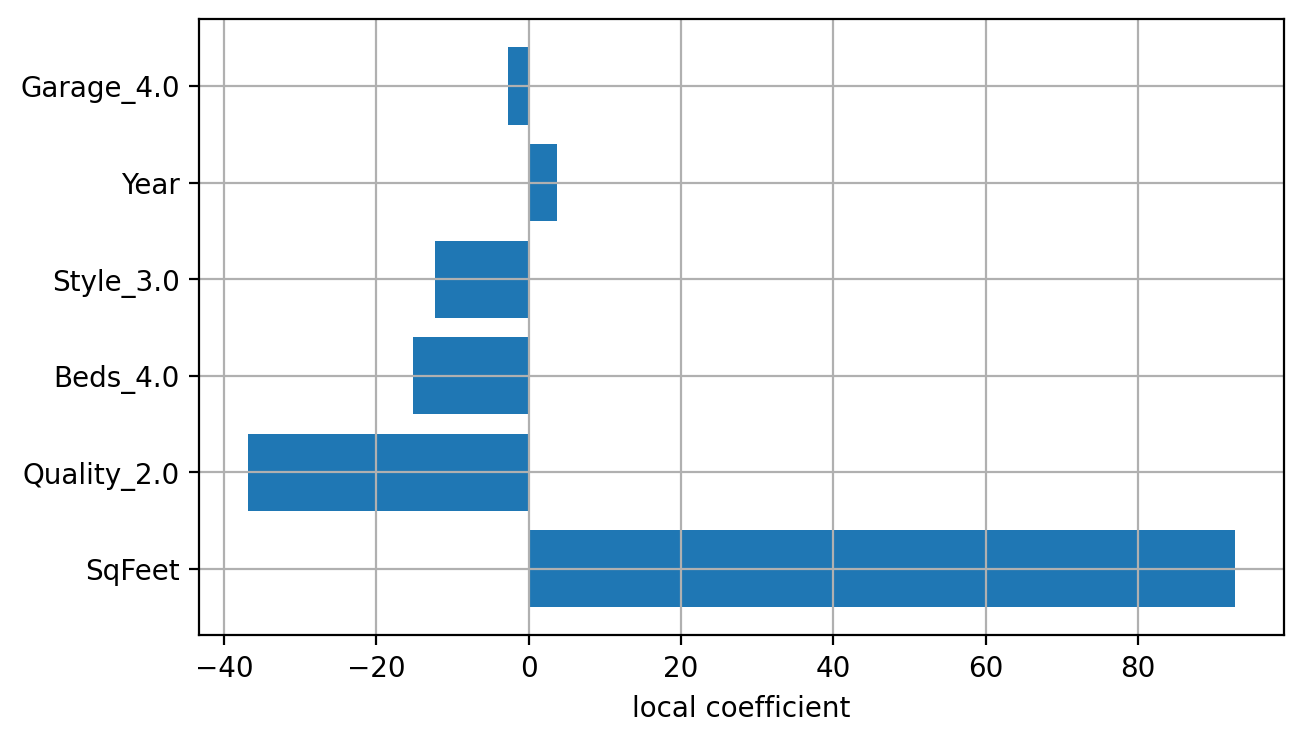

In [55]:
plt.figure(figsize=(7, 4))
plt.barh(explanation["feature"], explanation["coef"])
plt.xlabel("local coefficient")
plt.grid()
plt.show()

## SHAP

Значения Шепли как практический инструмент решают три проблемы сразу:
- оценка локального влияния прищнака на прогноз
- оценка глобального влияния признаков
- оценка взаимодействия признаков

За счет универсальности и согласованности, а также независимости от модели, это один из наиболее популярных методов интрепретации признаков. 

Изначально этот метод пришел из теории игр, поэтому нам нужны дополнительные определения:

1. **Коалиционная игра** - это пара $(N, v)$, где:
   - $N = \{1, 2, \ldots, M\}$ - множество игроков (в нашем случае - множество признаков)
   - $v: 2^N \rightarrow \mathbb{R}$ - характеристическая функция, которая ставит в соответствие каждой коалиции (подмножеству признаков) $S \subseteq N$ некоторое значение $v(S)$. В контексте машинного обучения это функция, которая возвращает предсказание модели при использовании только признаков из подмножества $S$:
   $$v(S) = E[f(X) | X_S = x_S]$$
   где $X_S$ - признаки из подмножества $S$, а $x_S$ - их конкретные значения для объясняемого объекта.

3. **Маргинальный вклад признака $i$** при добавлении к коалиции $S$:
   $$\Delta_i(S) = v(S \cup \{i\}) - v(S)$$
   Это разница между предсказанием модели с признаком $i$ и без него, при фиксированных значениях признаков из $S$.

**Формула значения Шепли:**

Значение Шепли для признака $i$ определяется как средневзвешенный маргинальный вклад по всем возможным коалициям:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(M - |S| - 1)!}{M!} [v(S \cup \{i\}) - v(S)]$$

где:
- $M$ - общее количество признаков
- $S$ - подмножество признаков без признака $i$
- $|S|$ - размер подмножества $S$
- $\frac{|S|!(M - |S| - 1)!}{M!}$ - весовой коэффициент, равный вероятности того, что признак $i$ будет добавлен к случайно выбранной коалиции размера $|S|$

**Алгоритм вычисления значения Шепли:**

1. **Для каждого признака $i \in \{1, 2, \ldots, M\}$:**
   
2. **Для каждой возможной коалиции $S \subseteq N \setminus \{i\}$:**
   - Вычислить предсказание модели $v(S)$ без признака $i$ (используя только признаки из $S$)
   - Вычислить предсказание модели $v(S \cup \{i\})$ с признаком $i$ (используя признаки из $S$ и признак $i$)
   - Вычислить маргинальный вклад: $\Delta_i(S) = v(S \cup \{i\}) - v(S)$
   - Вычислить вес коалиции: $w(S) = \frac{|S|!(M - |S| - 1)!}{M!}$

3. **Усреднить маргинальные вклады с весами:**
   $$\phi_i = \sum_{S \subseteq N \setminus \{i\}} w(S) \cdot \Delta_i(S)$$


**Свойства значений Шепли (аксиомы):**

1. **Эффективность (Efficiency)**: $\sum_{i=1}^{M} \phi_i = v(N) - v(\emptyset)$
   - Сумма всех значений Шепли равна разнице между предсказанием со всеми признаками и предсказанием без признаков

2. **Симметрия (Symmetry)**: Если $v(S \cup \{i\}) = v(S \cup \{j\})$ для всех $S$, то $\phi_i = \phi_j$
   - Признаки с одинаковым влиянием получают одинаковые значения

3. **Фиктивность (Dummy)**: Если $v(S \cup \{i\}) = v(S)$ для всех $S$, то $\phi_i = 0$
   - Признак, не влияющий на предсказание, получает нулевое значение

4. **Аддитивность (Additivity)**: Для двух игр $v$ и $w$: $\phi_i(v + w) = \phi_i(v) + \phi_i(w)$
   - Значения Шепли аддитивны относительно комбинации игр



In [56]:
import shap
#Локальное объяснение с shap

shap.initjs()
explainer = shap.TreeExplainer(model, feature_names=X_test_ohe.columns)
shap_values = explainer(X_test_ohe)

X_train_sc_df = pd.DataFrame(X_test_ohe, columns=X_test_ohe.columns)


Force Plot показывает локальное объяснение предсказания модели для одного объекта. На этом графике:
- Базовое значение (base value) - среднее предсказание модели на обучающей выборке.
- Ширина полосы отображает вклад.
- Финальное предсказание (output value) - результат суммирования базового значения и всех вкладов:
   $$f(x) = \text{base\_value} + \sum_{i=1}^{M} \phi_i$$
Признаки обычно отсортированы по величине вклада (по убыванию абсолютного значения).Вклад считается только для конкртеного семпла иотличается от глобальной важности (и можеет даже не совпадать по порядку с общей важностью)

Для классификации можно использовать аргумент link="logit", чтобы выводить логиты. Кроме того, для классификации удобно использовать другой стиль для неправильно отклассифицированных семплов (например через  highlight=misclassified)

In [57]:
# Визуализируем прогнозы для 5-го объекта в тестовых данных
shap.plots.force(shap_values[5, :])

Decision Plot показывает, как модель "принимает решение" для одного или нескольких объектов, показывая путь от базового значения к финальному предсказанию.
Ось Y - список признаков, отсортированных по важности (сверху вниз - от самых важных к менее важным)
Ось X - значения предсказания модели (обычно в шкале исходной задачи - например, цена дома или вероятность класса)
Каждая линия представляет один объект:
   - Линия начинается слева от базового значения (expected value)
   - Проходит через все признаки, накапливая их вклады
   - Заканчивается справа на финальном предсказании для этого объекта


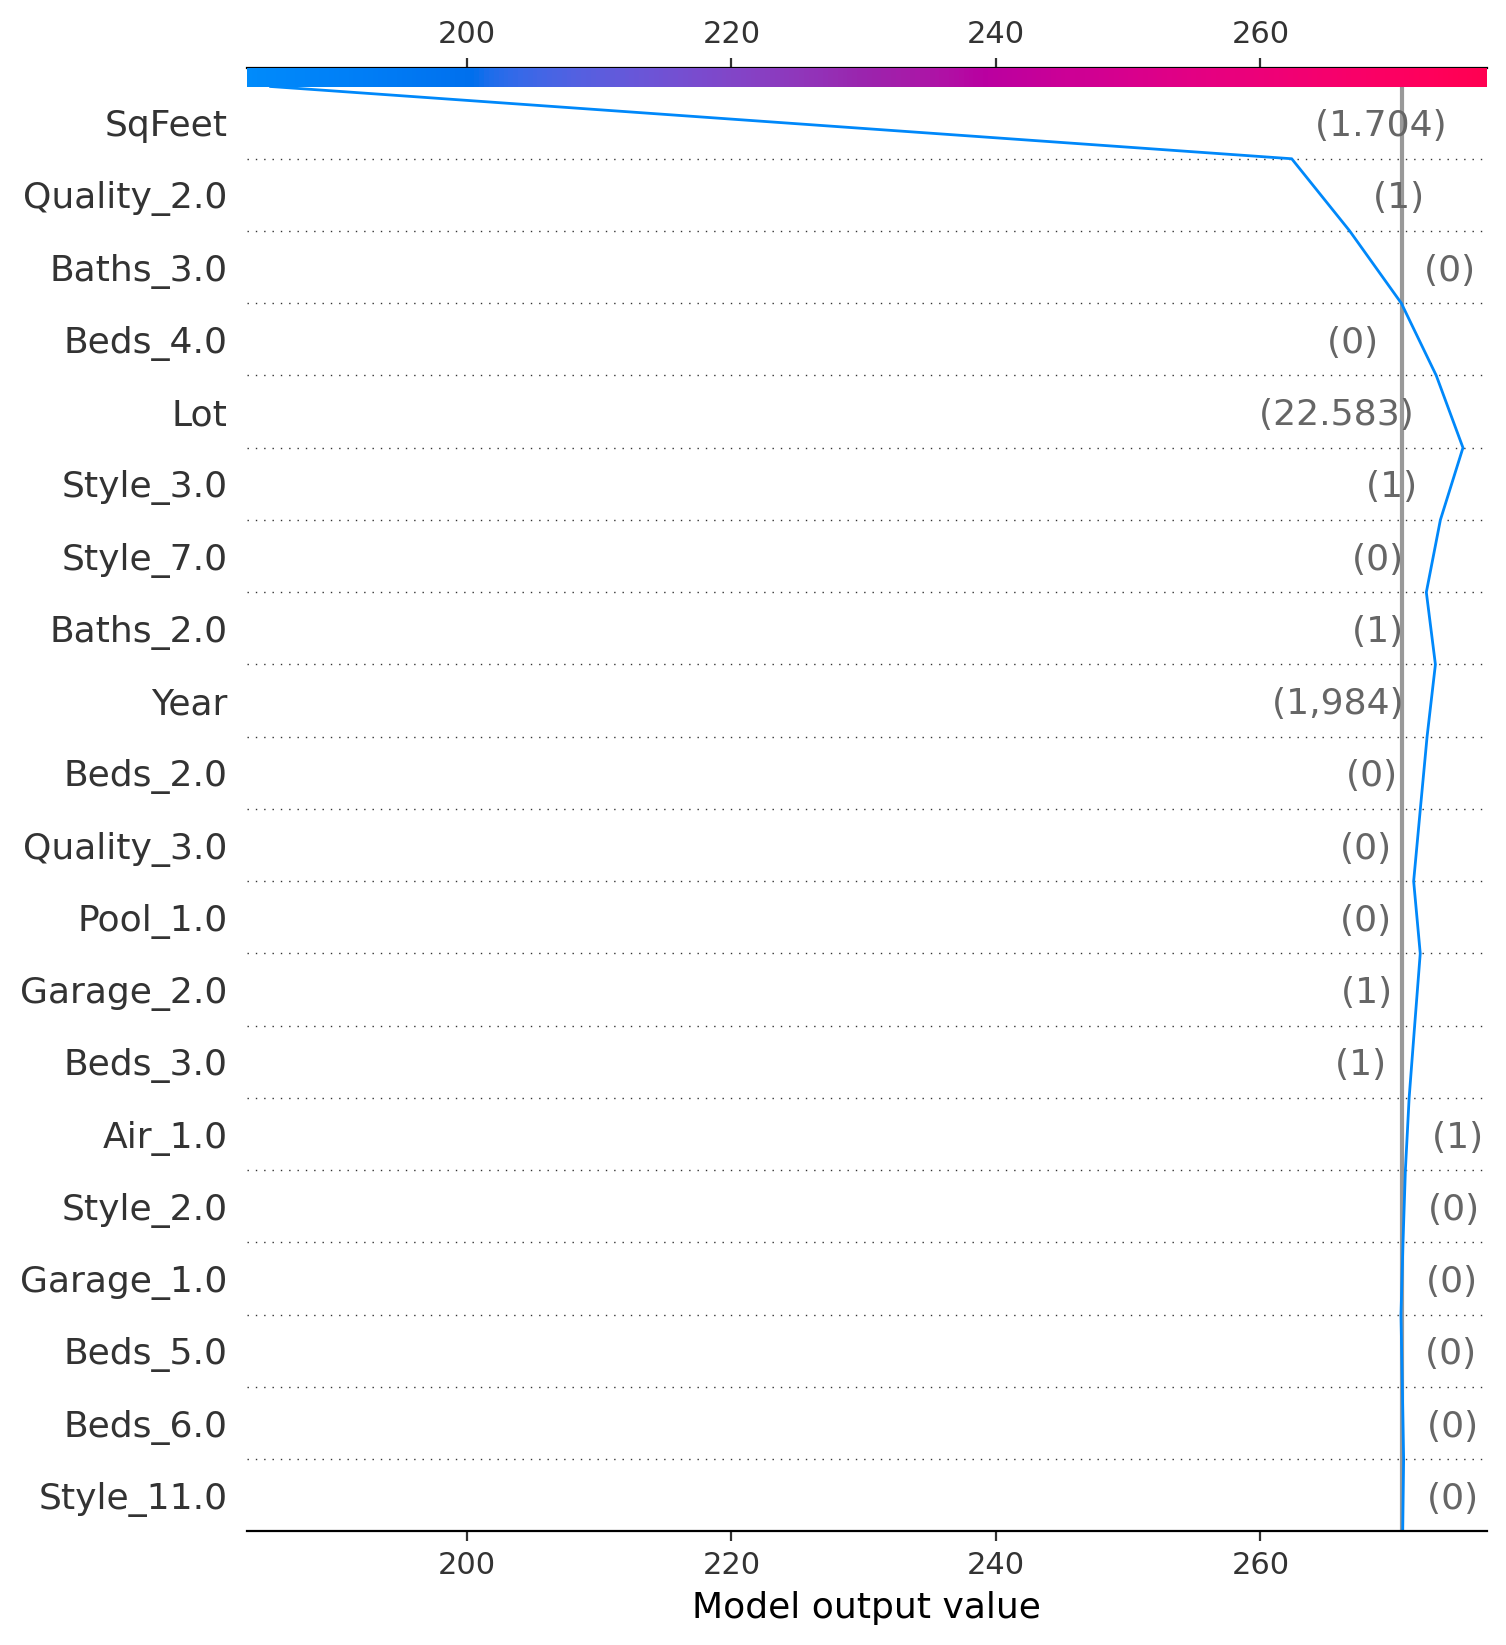

In [58]:
shap.decision_plot(
    explainer.expected_value, 
    explainer.shap_values(X_test_ohe[5:6]), 
    X_test_ohe[5:6]
)

Decision plot бывает удобнее force plot, например, когда число фичей велико и хочется явно увидеть их вклады. Кроме того, этот график поддерживает несколько выходов модели или позволяет сравнить несколько моделей.

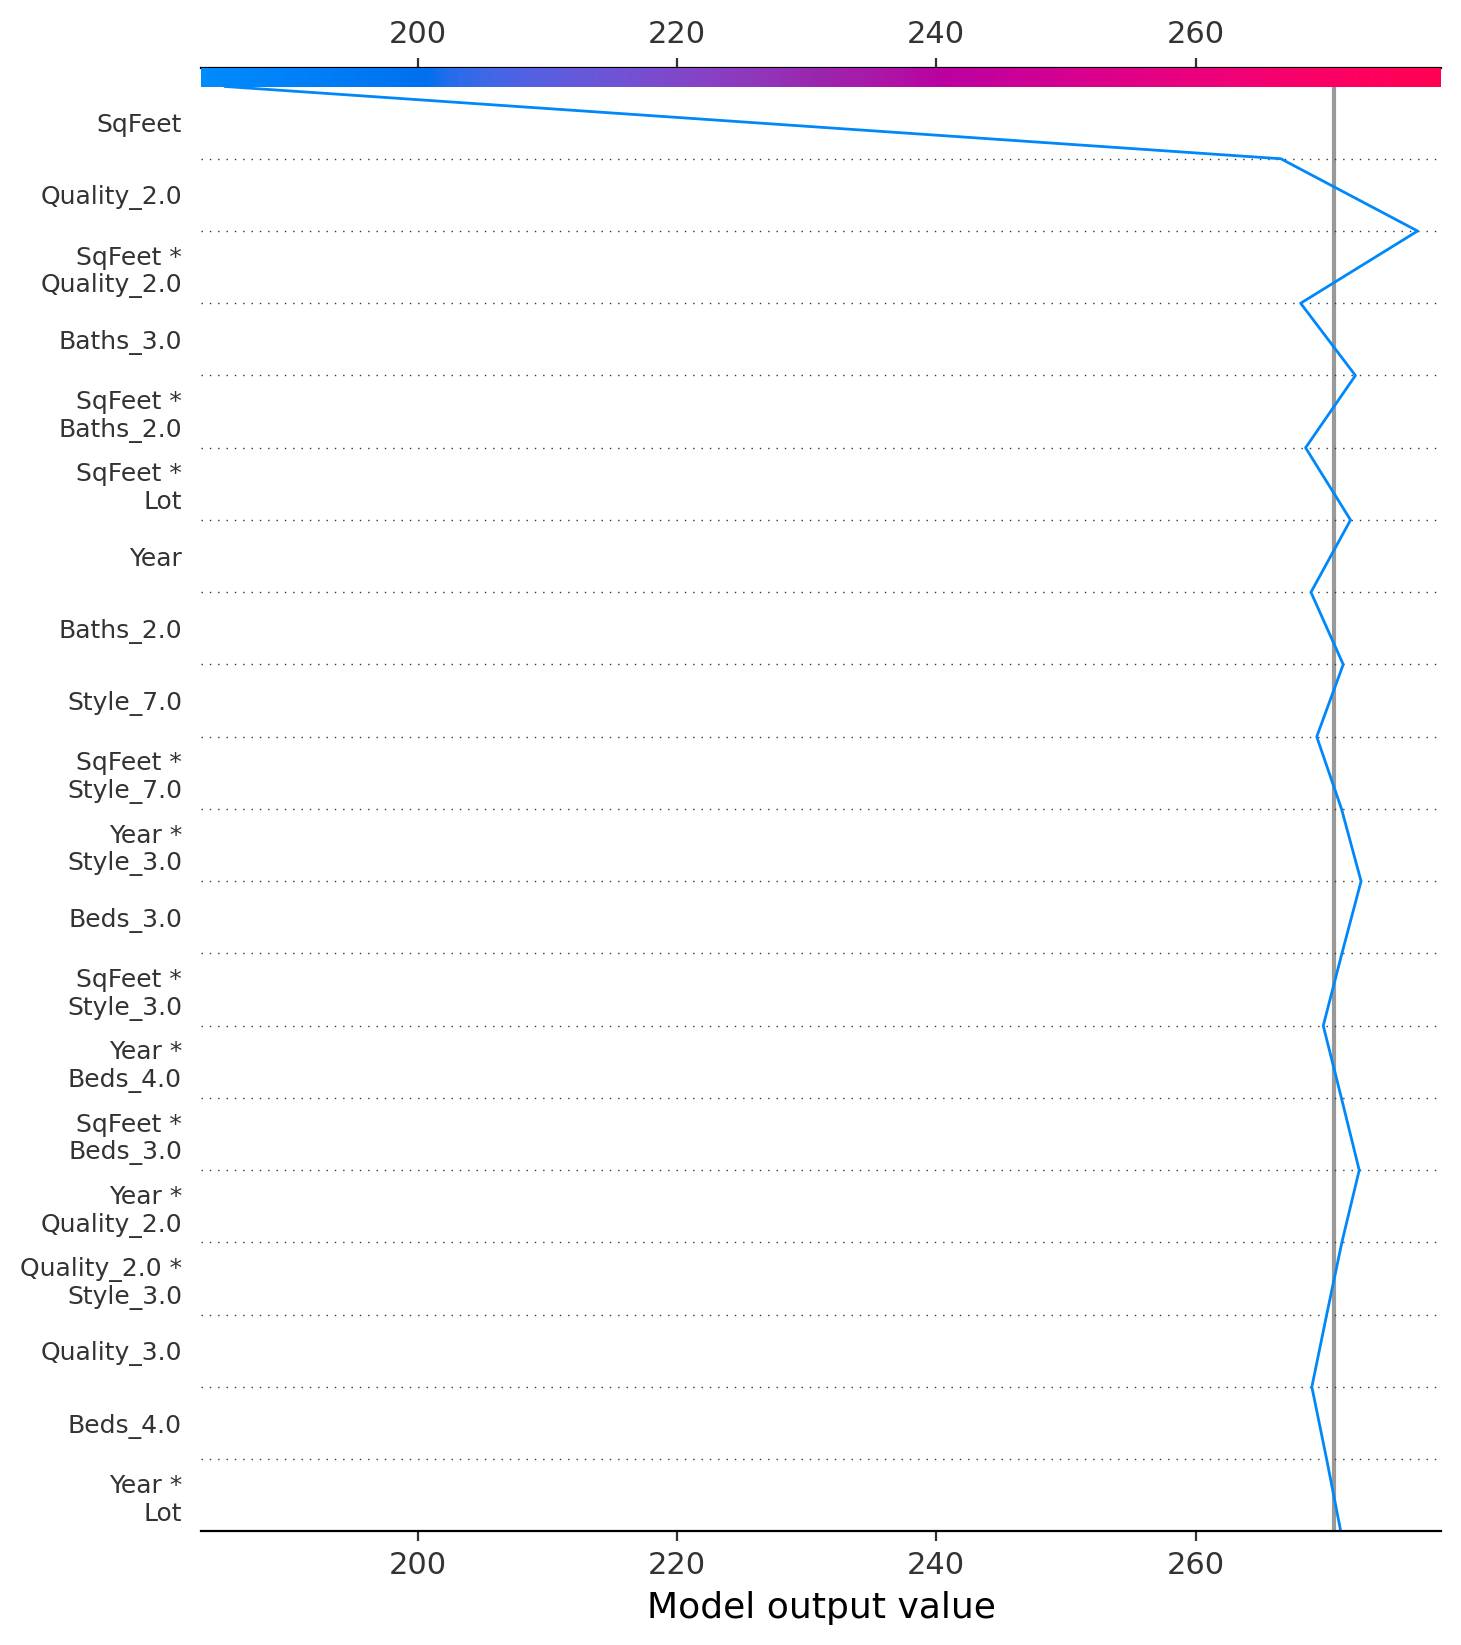

In [59]:
shap_interaction_values = explainer.shap_interaction_values(X_test_ohe[5:6])
shap.decision_plot(
    explainer.expected_value,
    shap_interaction_values,
    X_test_ohe[5:6]
)

С помощью этого графика можно также находить выбросы (если линии сильно отклоняются от стандартных), оценить гипотетические сценарии (что будет, если площадь дома изменится на 100 метров)

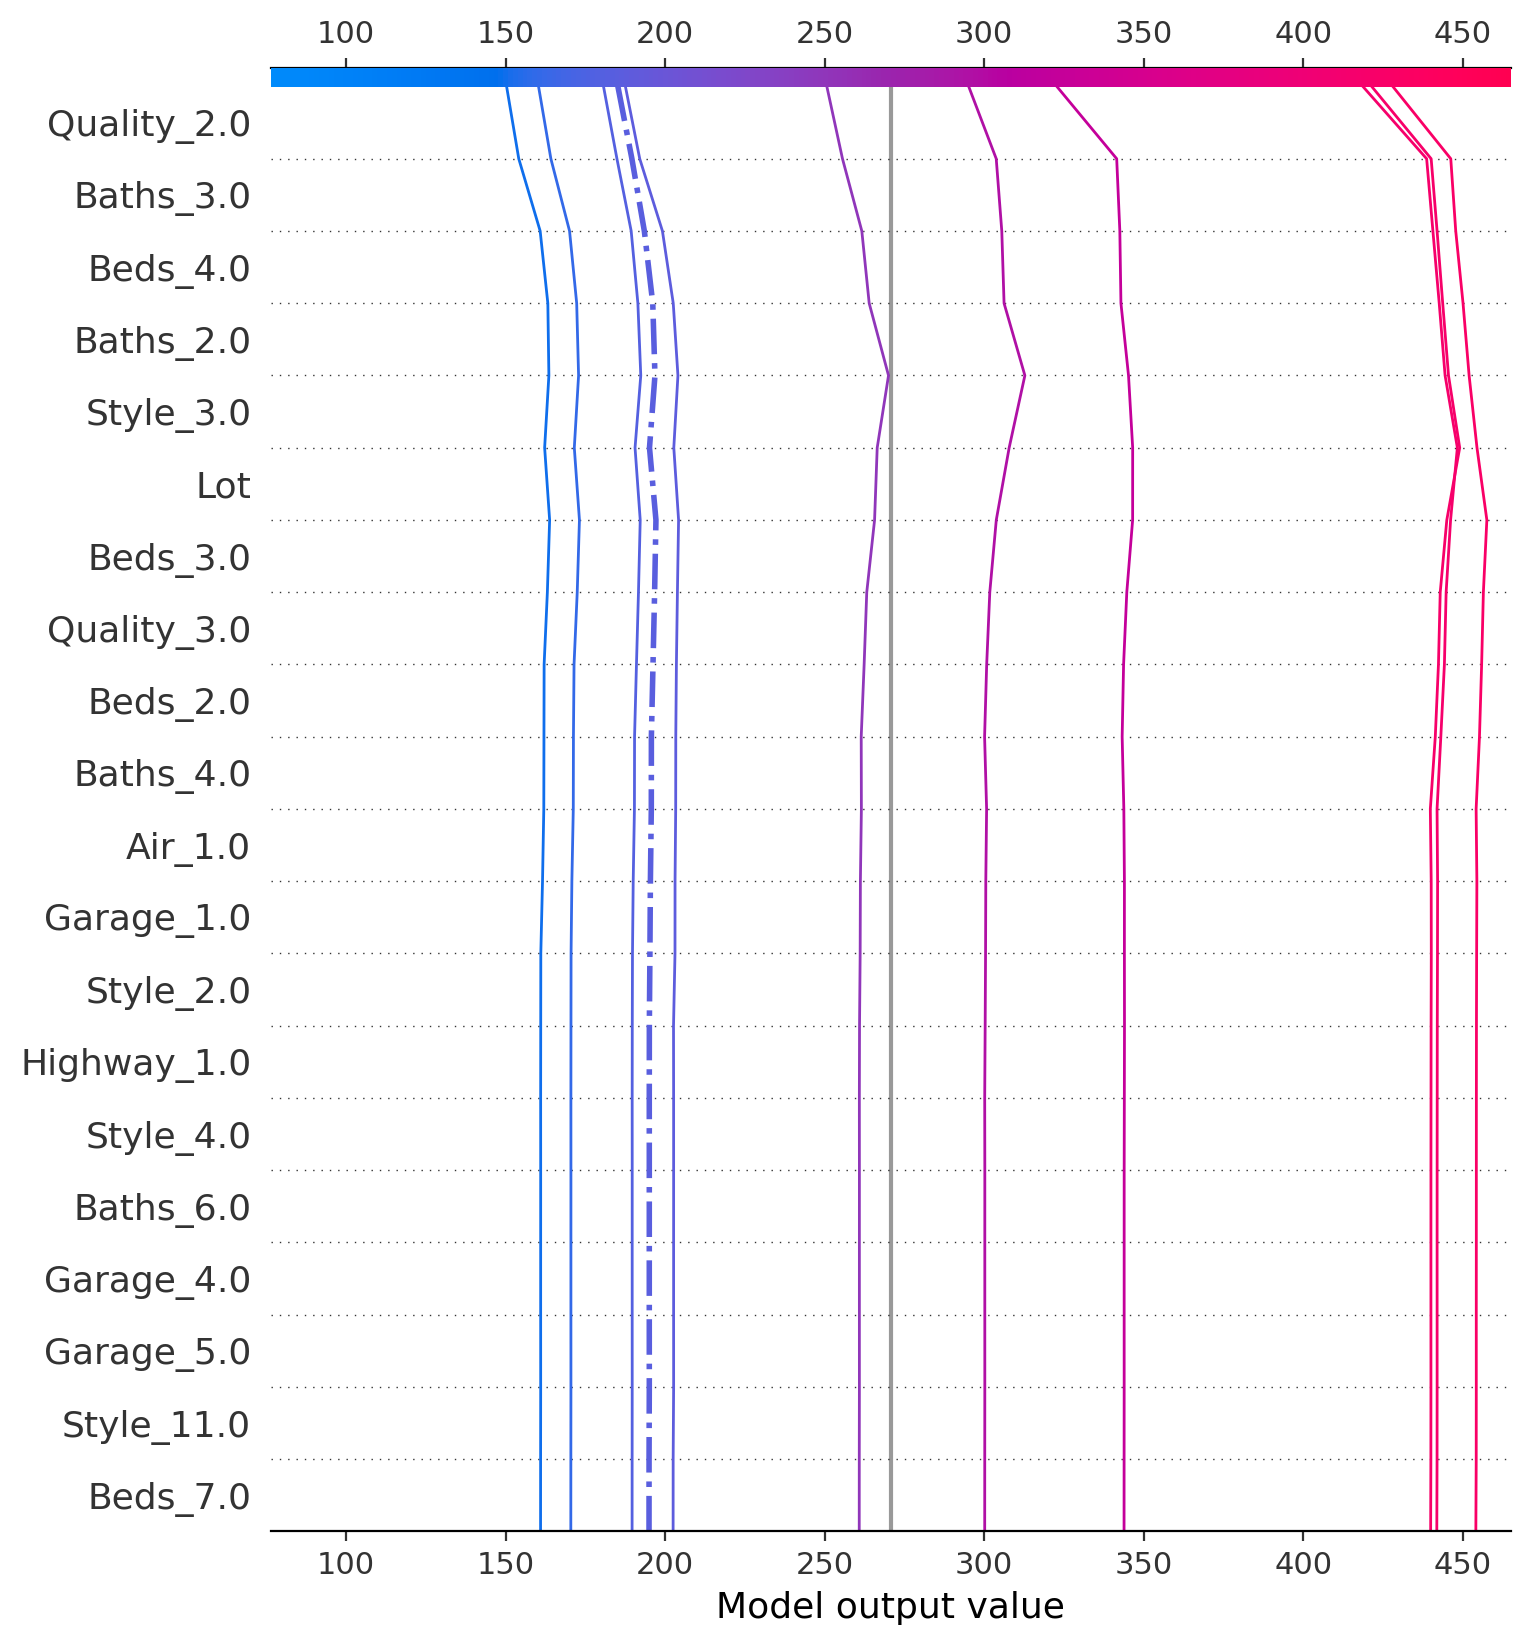

In [60]:
idx = 5
n_scenarios = 10
target_col = 'SqFeet'
original_sample = X_test_ohe.iloc[idx: idx+1].copy()

# Создаем выборку, заменяя значение признака на выбранную из интервала (+- половина всего интервала значений столбца)
original_val = original_sample[target_col].values[0]

val_min = X_train[target_col].min()
val_max = X_train[target_col].max()
val_range = val_max - val_min

values = np.linspace(
    max(val_min, original_val - 0.5 * val_range),
    min(val_max, original_val + 0.5 * val_range),
    n_scenarios
)

hypothetical_samples = []
for val in values:
    sample = original_sample.copy()
    sample[target_col] = val
    hypothetical_samples.append(sample)

hypothetical_df = pd.concat(hypothetical_samples, ignore_index=True)

all_samples = pd.concat([original_sample, hypothetical_df], ignore_index=True)
all_shap_values = explainer.shap_values(all_samples)

original_idx_in_all = 0

shap.decision_plot(
    explainer.expected_value,
    all_shap_values,
    all_samples,
    highlight=[original_idx_in_all],
    feature_order="hclust", #  features are ordered via hierarchical clustering to group similar prediction paths 
)


Перейдем к глобальной интерпретации. Ее можно провести, построив общий график, где каждая точка будет соответствовать одному семплу.

In [61]:
X_train_sc.shape # очень много семплов!

(13314, 10)

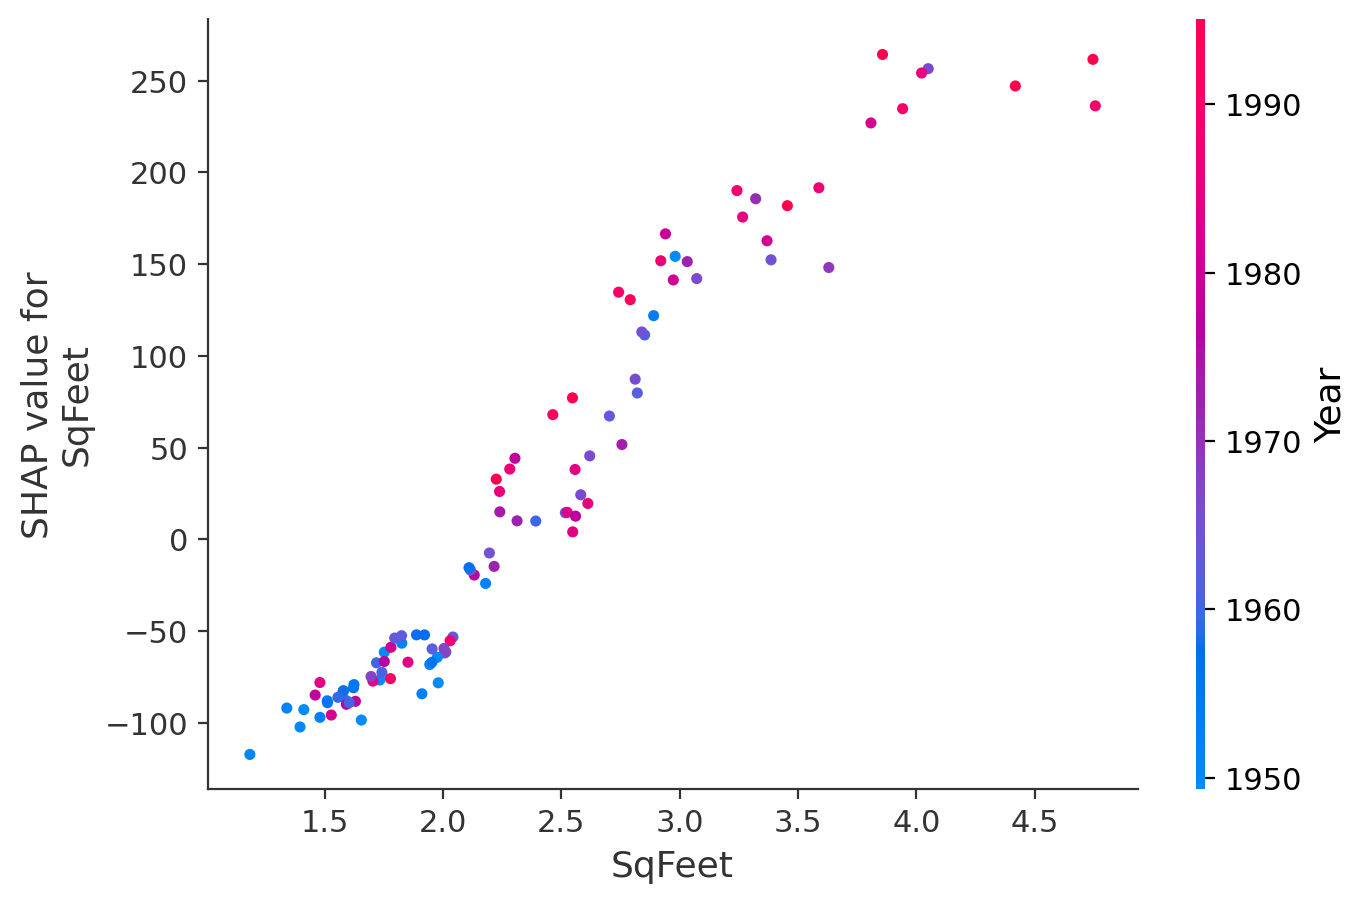

In [62]:
shap.dependence_plot("SqFeet", shap_values.values[:100], X_train_sc_df[:100], interaction_index="Year")

In [63]:
# глобальное поведение через force plot
shap.initjs()

#Посмотрим на график для первых 100 объектов тренировочного набора данных
shap.plots.force(shap_values[:100])

На графике — наблюдения, отсортированные в выбранном порядке (панель сверху). По умолчанию наблюдения остортированы по близости друг к другу (и по оси x — номер наблюдения в отсортированном ряду), а по оси y располагается прогноз модели.

Для y отображения можно выбирать различные признаки — и тогда будет видно, как конкретный признак менял output модели.

Иногда мы не знаем заранее, какой признак мы хотим вывести. Поэтому можно отрисовать самый важный по мнению Shap. В таком случае, мы хотим узнать глобальную важность признака как среднее значение shap и отсортировать признаки по этому значению (в целом, мы так в принципе можем автоматизировать выбор признака). Заодно посмотри на более простой график значений shap.

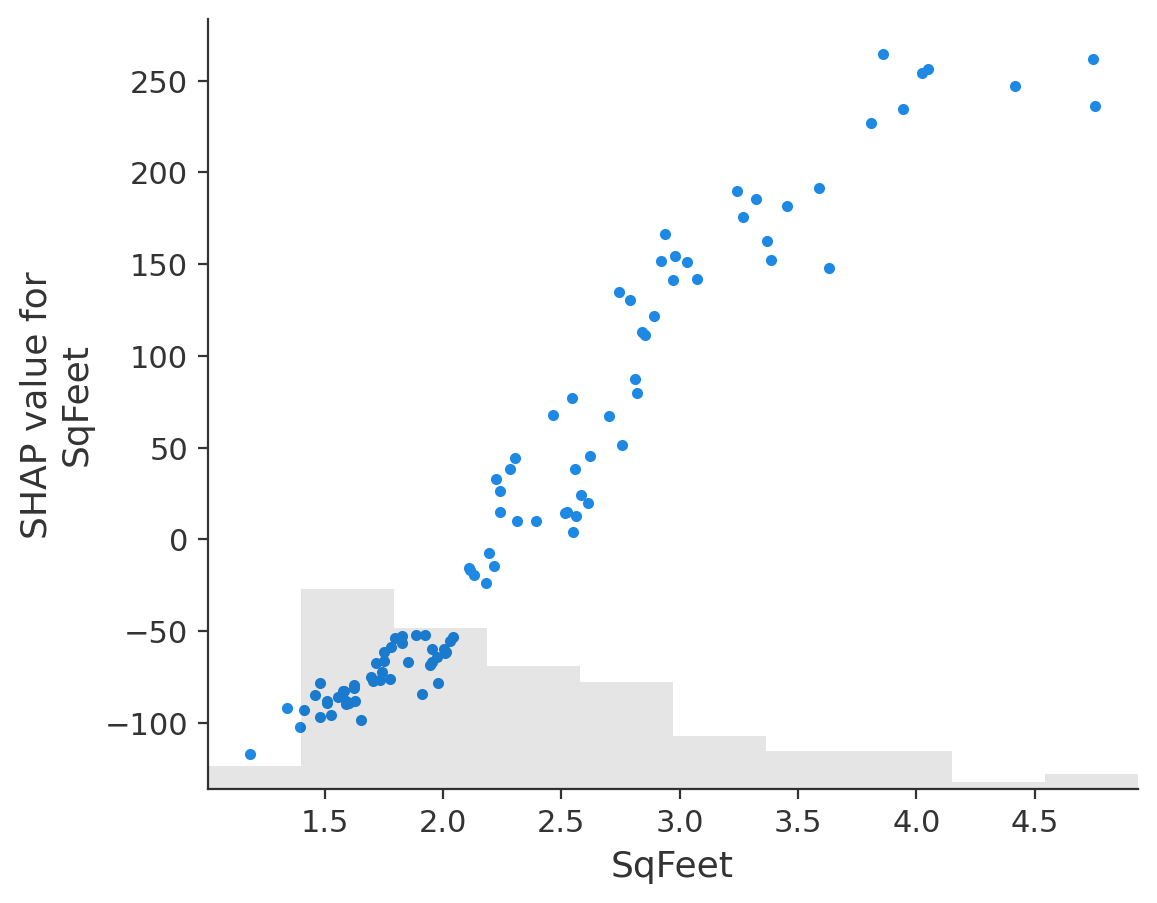

In [64]:
shap.plots.scatter(shap_values[:100,  shap_values.abs.mean(0).argsort[-1]])

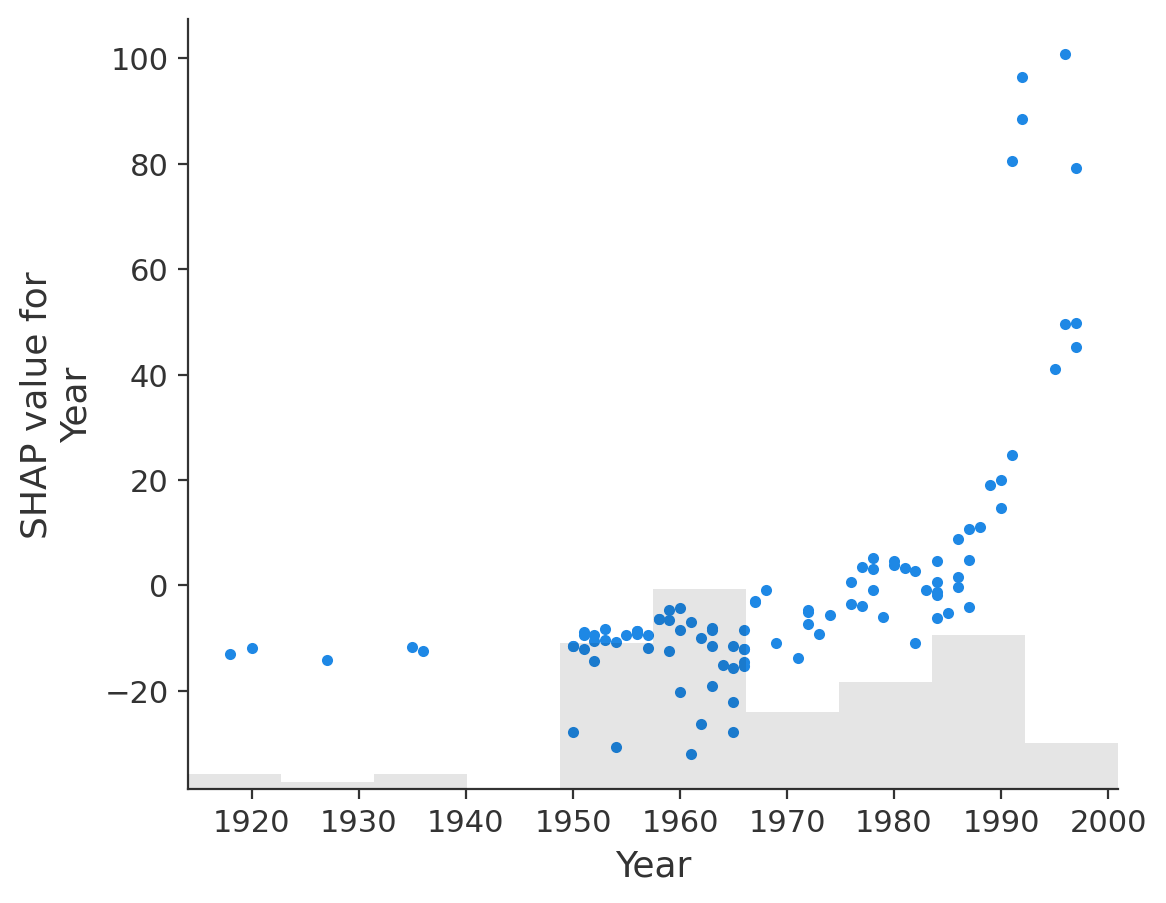

In [65]:
# Второй по важности
shap.plots.scatter(shap_values[:100,  shap_values.abs.mean(0).argsort[-2]])

Мы можем также и узнать взаимодействие двух признаков - отрисовать значения для 1 признака, раскрасив график с помощью второго:


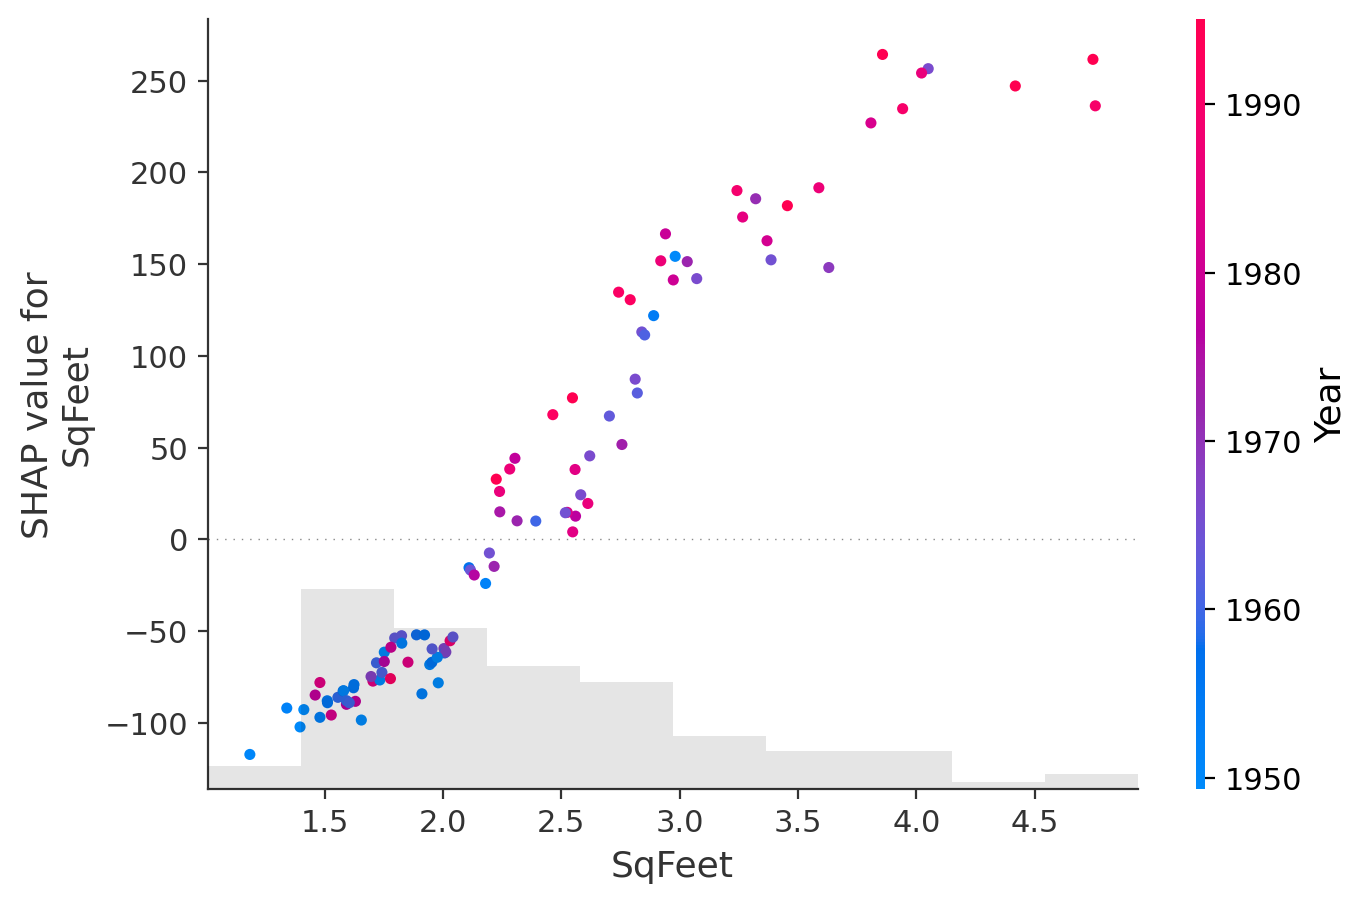

In [66]:
shap.plots.scatter(shap_values[:100,  shap_values.abs.mean(0).argsort[-1]], color = shap_values[:100,  shap_values.abs.mean(0).argsort[-2]])

**Задание:** постройте интерпретацию и для других признаков (хотя бы пары). Сделайте выводы об их влиянии на прогноз в целом и нескольких примеров.

In [67]:
# Глобальная важность

shap_importance = pd.DataFrame({
    "feature": X_test_ohe.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(10)

,feature,mean_abs_shap
0,SqFeet,90.161370
1,Year,15.200678
23,Quality_2.0,11.668397
2,Lot,7.749771
10,Baths_3.0,6.446379
5,Beds_4.0,2.397036
30,Style_7.0,1.914807
24,Quality_3.0,1.903363
9,Baths_2.0,1.120720
22,Pool_1.0,0.990981


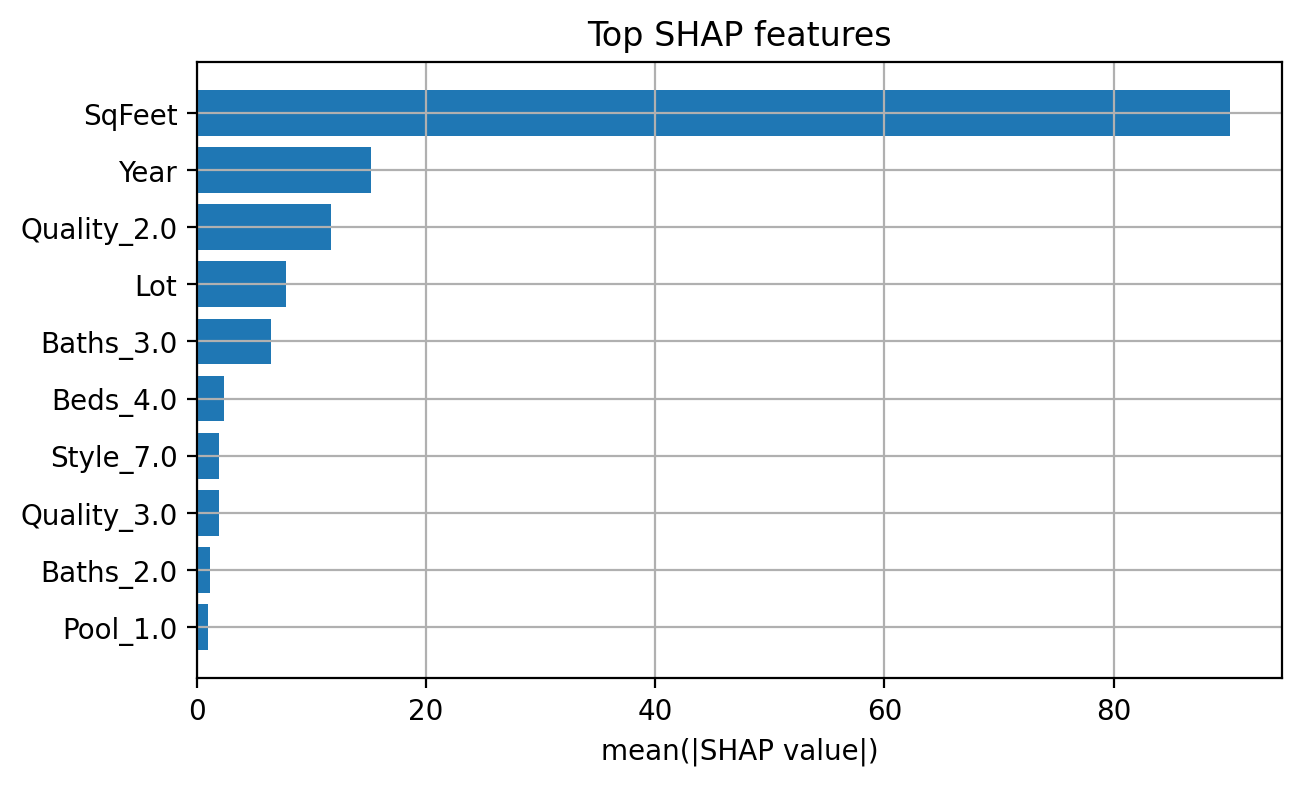

In [68]:
plt.figure(figsize=(7, 4))
plt.barh(shap_importance["feature"].head(10)[::-1], shap_importance["mean_abs_shap"].head(10)[::-1])
plt.xlabel("mean(|SHAP value|)")
plt.title("Top SHAP features")
plt.grid()
plt.show()

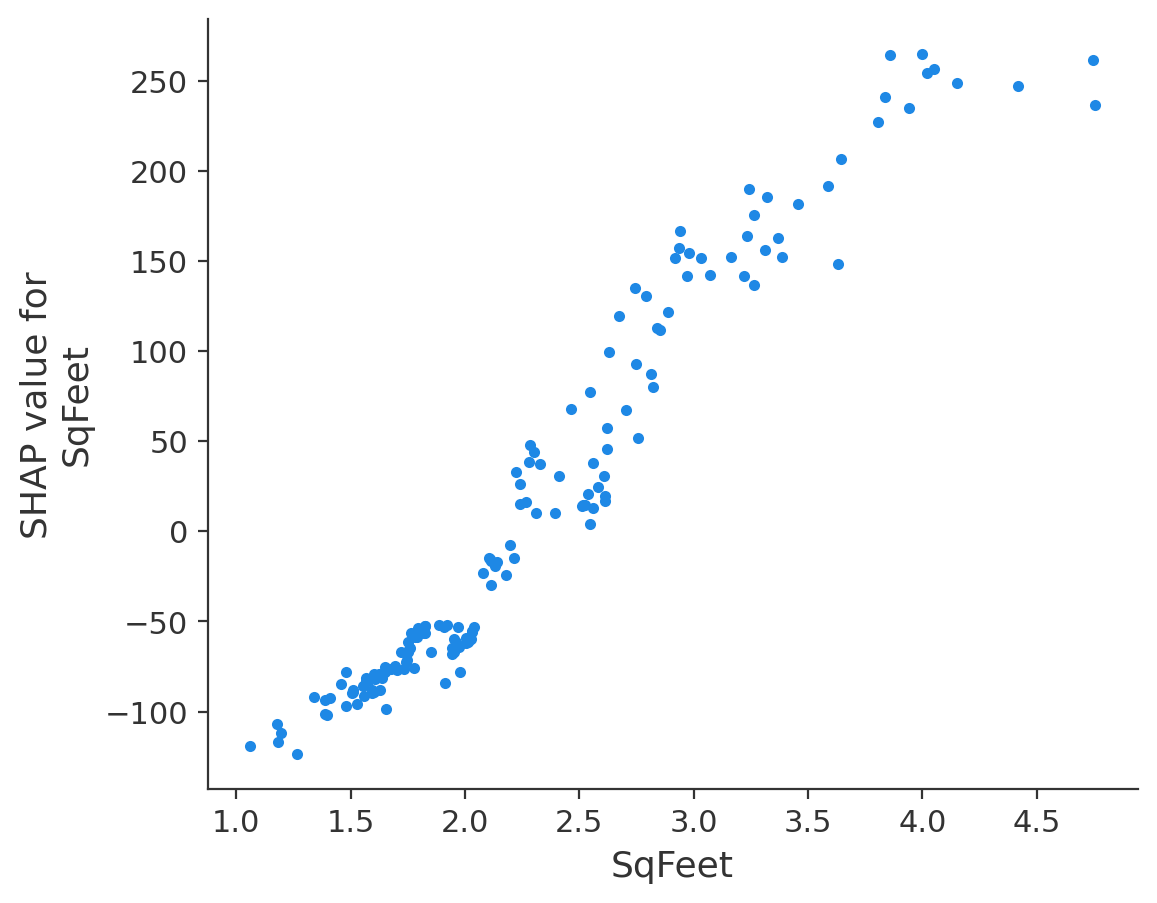

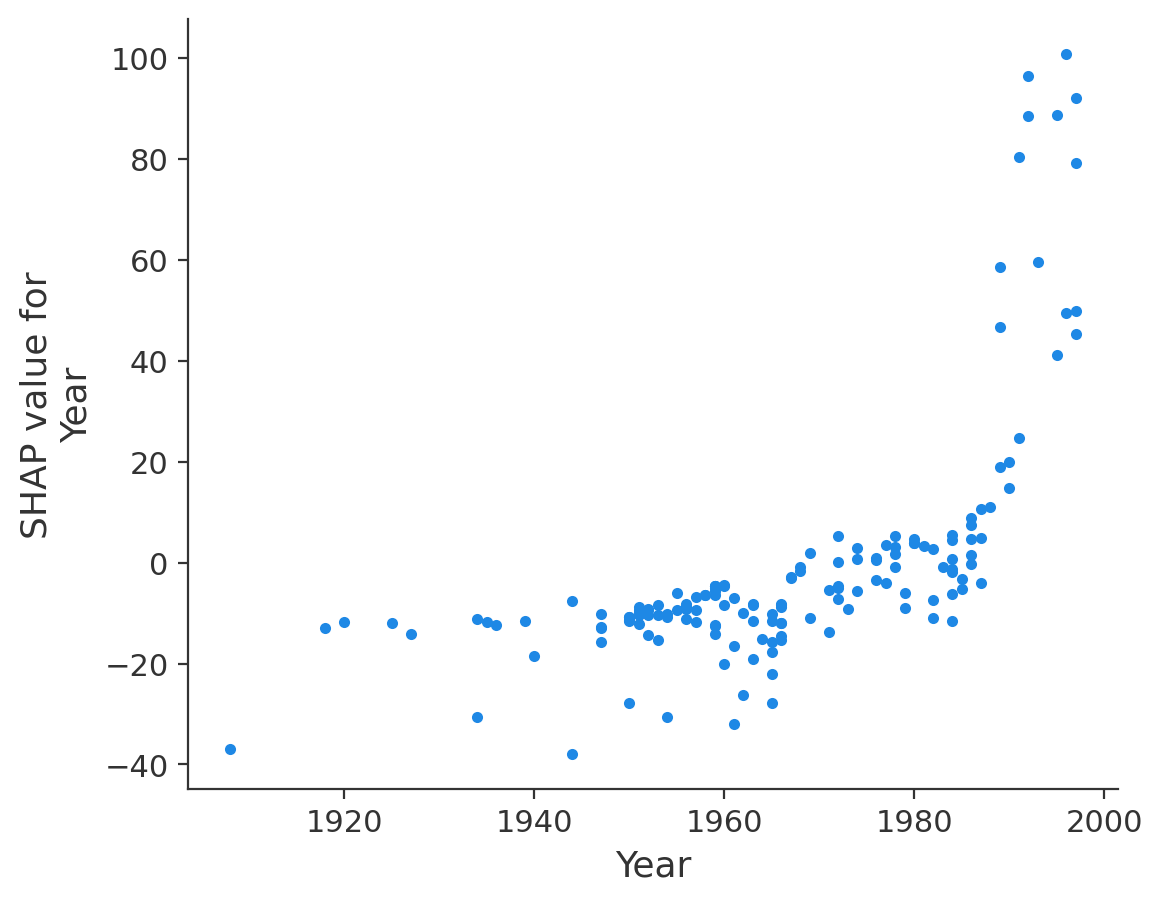

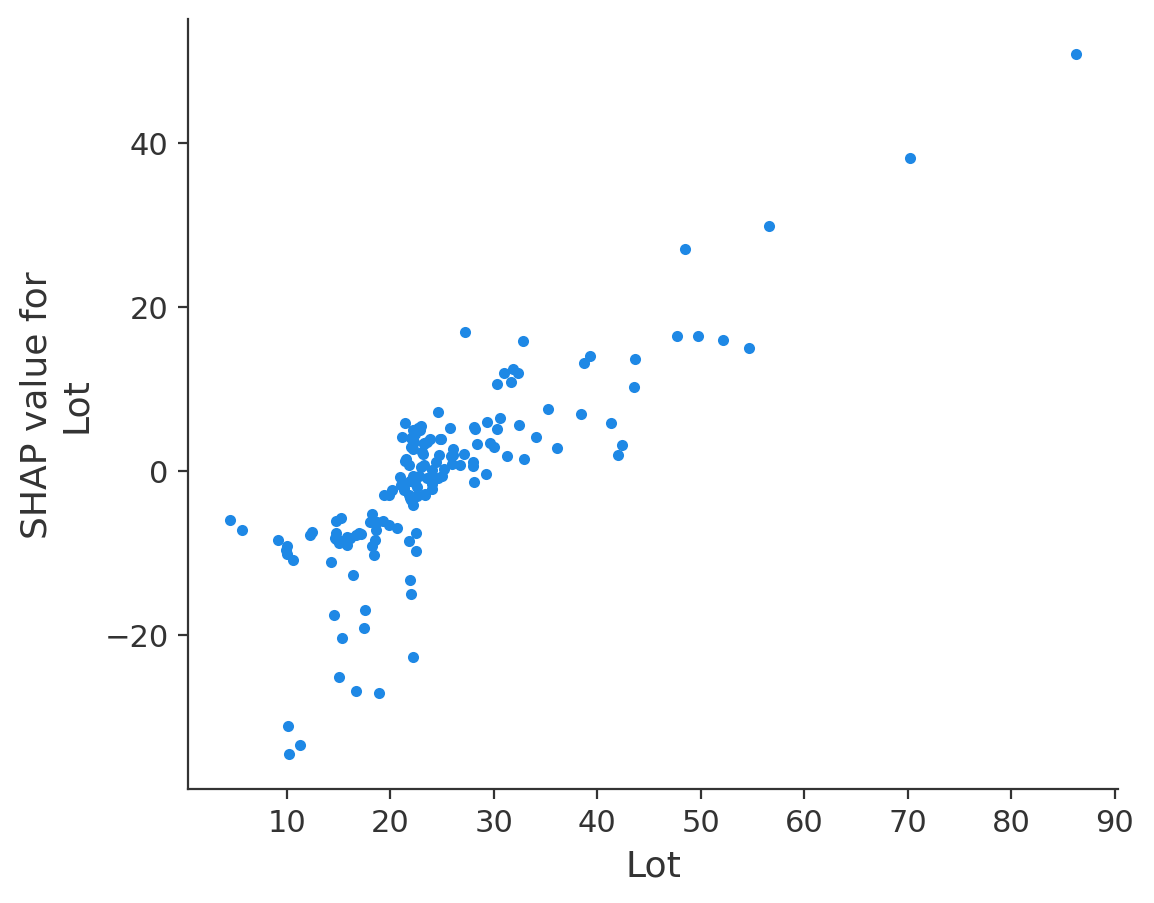

In [69]:
# SHAP dependence plots для нескольких признаков

features_to_plot = ["SqFeet", "Year", "Lot"]

for feature in features_to_plot:
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_test_ohe,
        interaction_index=None
    )

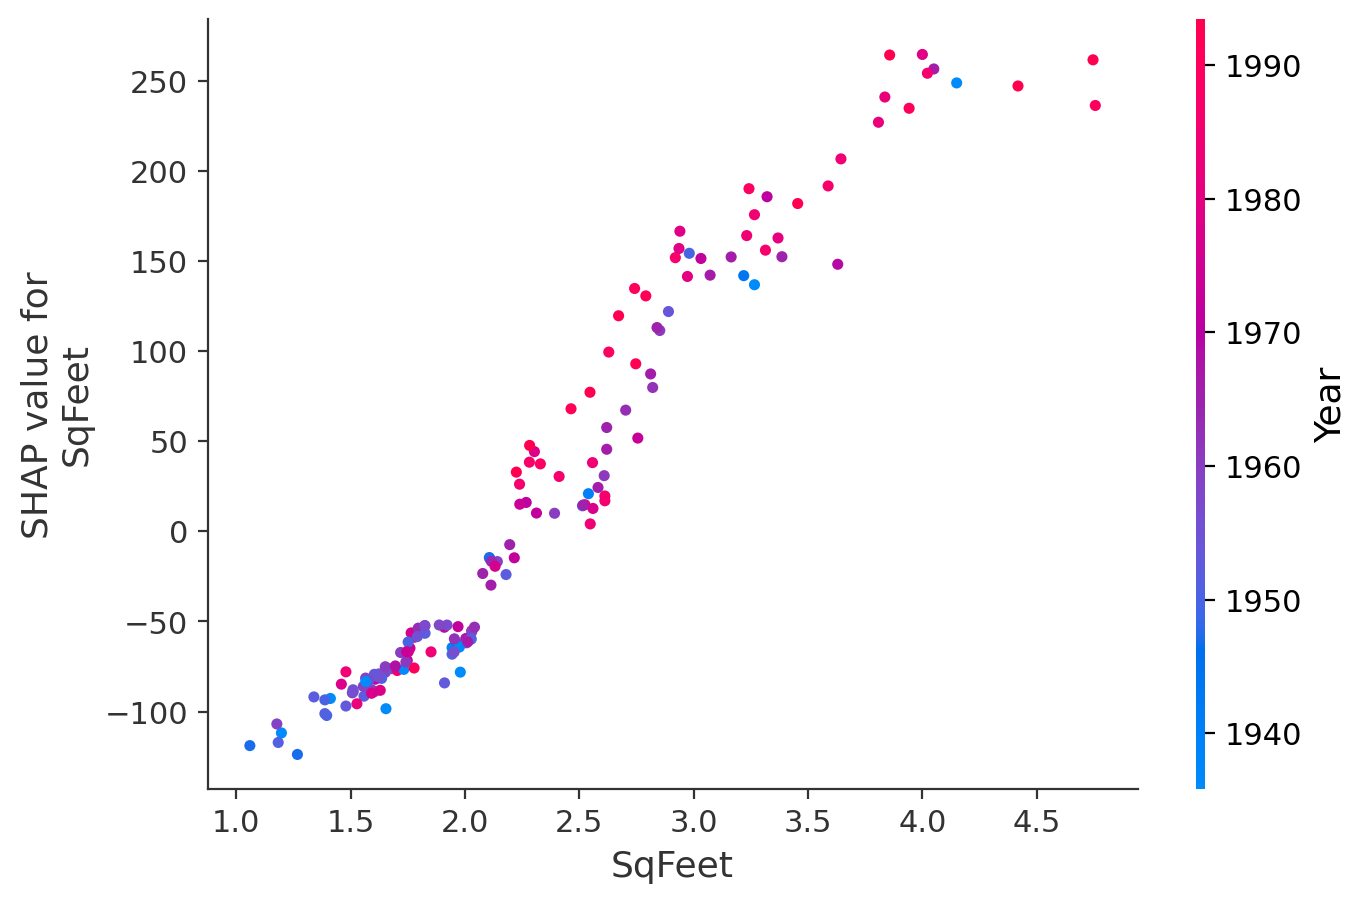

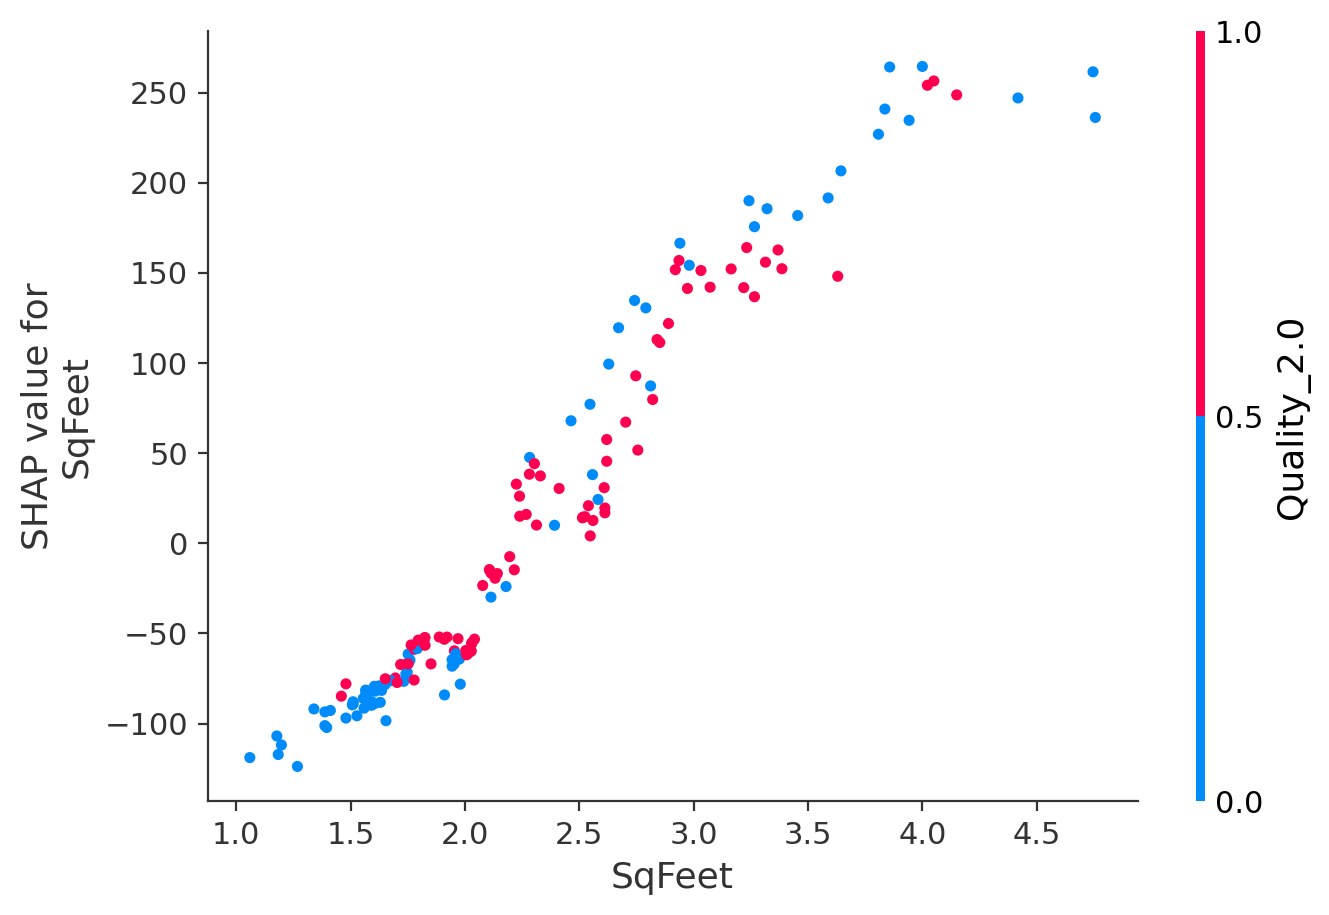

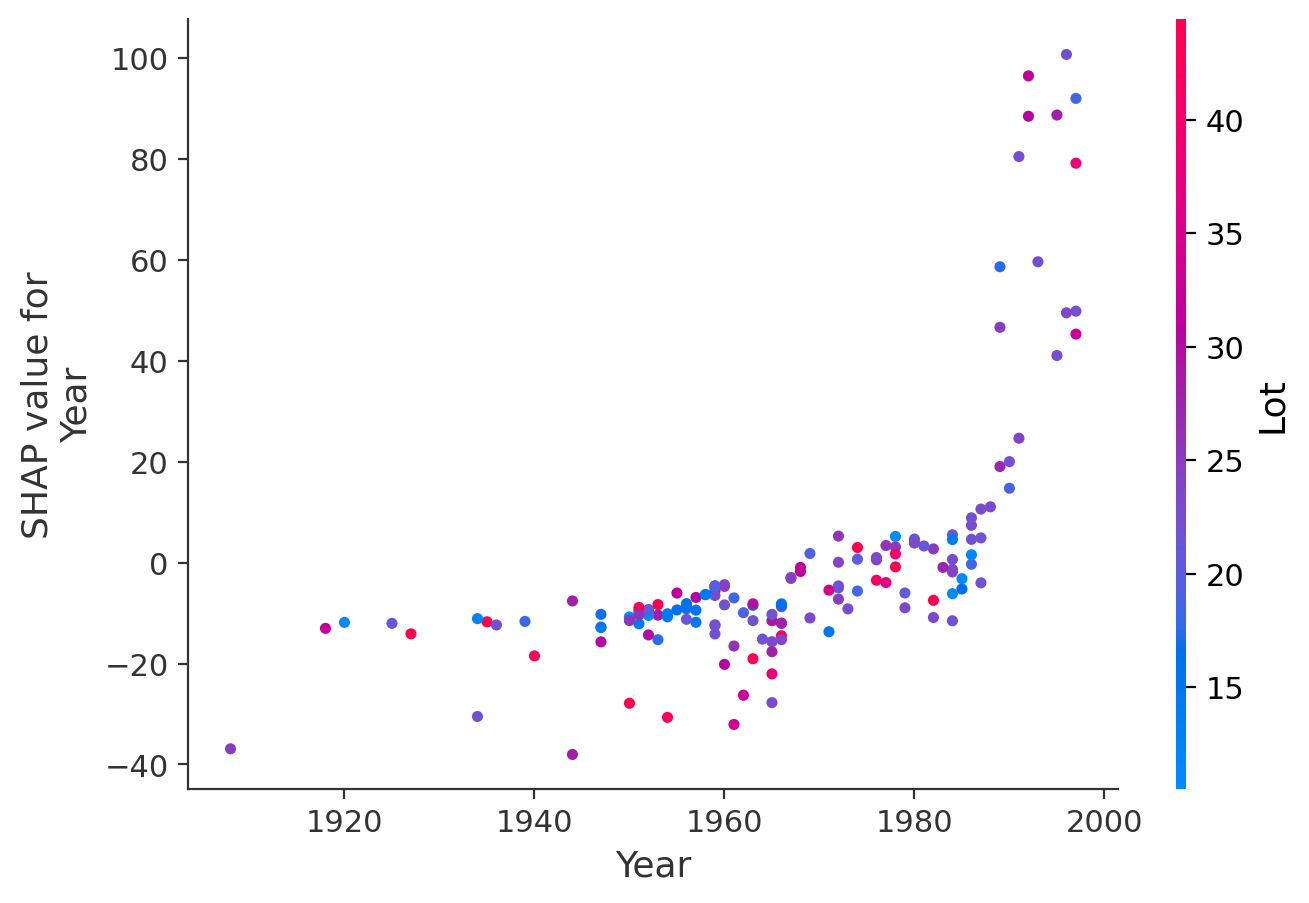

In [70]:
feature_pairs = [
    ("SqFeet", "Year"),
    ("SqFeet", "Quality_2.0"),
    ("Year", "Lot")
]

for main_feature, interaction_feature in feature_pairs:
    shap.dependence_plot(
        main_feature,
        shap_values.values,
        X_test_ohe,
        interaction_index=interaction_feature
    )

In [71]:
for idx in [0, 5, 10]:
    print("Object:", idx)
    print("Prediction:", model.predict(X_test_ohe.iloc[[idx]])[0])
    
    local_explanation = pd.DataFrame({
        "feature": X_test_ohe.columns,
        "shap_value": shap_values.values[idx],
        "feature_value": X_test_ohe.iloc[idx].values
    })
    
    local_explanation["abs_shap"] = local_explanation["shap_value"].abs()
    display(local_explanation.sort_values("abs_shap", ascending=False).head(8))

Object: 0
Prediction: 151.44399999999993


,feature,shap_value,feature_value,abs_shap
0,SqFeet,-91.871834,1.340,91.871834
1,Year,-10.460039,1952.000,10.460039
2,Lot,-7.192824,5.666,7.192824
10,Baths_3.0,-5.849084,0.000,5.849084
23,Quality_2.0,5.801674,0.000,5.801674
24,Quality_3.0,-3.397914,1.000,3.397914
5,Beds_4.0,-2.427284,0.000,2.427284
17,Garage_2.0,-2.167817,0.000,2.167817


Object: 5
Prediction: 185.17026


,feature,shap_value,feature_value,abs_shap
0,SqFeet,-77.196698,1.704,77.196698
23,Quality_2.0,-4.385702,1.000,4.385702
10,Baths_3.0,-3.902719,0.000,3.902719
5,Beds_4.0,-2.639312,0.000,2.639312
2,Lot,-2.020122,22.583,2.020122
26,Style_3.0,1.709060,1.000,1.709060
30,Style_7.0,1.061175,0.000,1.061175
9,Baths_2.0,-0.686099,1.000,0.686099


Object: 10
Prediction: 197.415


,feature,shap_value,feature_value,abs_shap
0,SqFeet,-75.824640,1.778,75.824640
1,Year,24.651957,1991.000,24.651957
23,Quality_2.0,-6.575366,1.000,6.575366
10,Baths_3.0,-6.378829,0.000,6.378829
5,Beds_4.0,-3.030013,0.000,3.030013
2,Lot,-2.247405,24.022,2.247405
3,Beds_2.0,-1.509542,1.000,1.509542
9,Baths_2.0,-0.937608,1.000,0.937608


Основной недостаток метода - вычислительная сложность, так как для n признаков необходимо перебрать $2^n$ подмножеств. Для больших n используются приближенные алгоритмы (KernelShap, TreeShap).